# Checkpoint Reconstruction Analysis

TODOs answered here:

1. What is the relationship between sequence length and reconstruction loss?
2. How does the reconstruction loss evolve over epochs for different sequence lengths?
3. Are there some amino acids that are more likely to be reconstructed incorrectly?

`outputs/output_results.csv` contains per-example `token_accuracy`, but not per-example cross-entropy loss or epoch. This notebook uses `1 - token_accuracy` as a per-example reconstruction-error proxy for questions 1 and 3. Question 2 can only be answered by sequence-length bin if per-epoch reconstruction outputs are saved; the notebook plots available global history now and includes a guarded cell for future per-epoch length-binned files.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs" / "output_results.csv").exists():
    for parent in Path.cwd().parents:
        if (parent / "outputs" / "output_results.csv").exists():
            PROJECT_ROOT = parent
            break

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib_cache"))
(PROJECT_ROOT / ".matplotlib_cache").mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RESULTS_PATH = PROJECT_ROOT / "outputs" / "output_results.csv"
HISTORY_DIR = PROJECT_ROOT / "history"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results CSV: {RESULTS_PATH}")

Project root: /Users/josh/GWU/protein-sequence-augmentation
Results CSV: /Users/josh/GWU/protein-sequence-augmentation/outputs/output_results.csv


In [2]:
results = pd.read_csv(RESULTS_PATH)
numeric_cols = ["target_length", "predicted_length", "token_accuracy"]
results[numeric_cols] = results[numeric_cols].apply(pd.to_numeric, errors="coerce")
results = results.dropna(subset=numeric_cols).copy()

# output_results.csv does not include cross-entropy loss, so this is a token-error proxy.
results["reconstruction_error"] = 1.0 - results["token_accuracy"]
results["length_delta"] = results["predicted_length"] - results["target_length"]
results["abs_length_delta"] = results["length_delta"].abs()
results["length_bin"] = pd.qcut(
    results["target_length"],
    q=4,
    labels=["short", "medium-short", "medium-long", "long"],
    duplicates="drop",
)

summary = results[["target_length", "predicted_length", "token_accuracy", "reconstruction_error", "length_delta"]].describe()
display(summary)
display(results.groupby("length_bin", observed=True)[["target_length", "token_accuracy", "reconstruction_error", "abs_length_delta"]].agg(["count", "mean", "median", "std"]))

,target_length,predicted_length,token_accuracy,reconstruction_error,length_delta
count,1493.000000,1493.000000,1493.000000,1493.000000,1493.000000
mean,213.213664,213.184863,0.777548,0.222452,-0.028801
std,86.238971,86.209208,0.132422,0.132422,0.290328
min,34.000000,34.000000,0.215139,0.000000,-2.000000
25%,141.000000,141.000000,0.663333,0.100592,0.000000
50%,211.000000,210.000000,0.784689,0.215311,0.000000
75%,284.000000,284.000000,0.899408,0.336667,0.000000
max,377.000000,377.000000,1.000000,0.784861,1.000000


target_length                               token_accuracy  \
                     count        mean median        std          count   
length_bin                                                                
short                  379  105.817942  107.0  24.088046            379   
medium-short           374  173.708556  171.0  20.924685            374   
medium-long            370  248.251351  249.0  20.931792            370   
long                   370  328.116216  325.0  26.428202            370   

                                           reconstruction_error            \
                  mean    median       std                count      mean   
length_bin                                                                  
short         0.929679  0.933333  0.032755                  379  0.070321   
medium-short  0.850085  0.851580  0.048294                  374  0.149915   
medium-long   0.720775  0.719512  0.056211                  370  0.279225   
long          0.605168  0.605516  0.046427                  370  0.394832   

                                 abs_length_delta                             
                median       std            count      mean median       std  
length_bin                                                                    
short         0.066667  0.032755              379  0.015831    0.0  0.124987  
medium-short  0.148420  0.048294              374  0.018717    0.0  0.135704  
medium-long   0.280488  0.056211              370  0.062162    0.0  0.241777  
long          0.394484  0.046427              370  0.235135    0.0  0.437235

## 1. Sequence Length vs Reconstruction Error

The scatter/LOWESS plot shows whether longer sequences tend to have higher token reconstruction error. The boxplot compares the same error proxy across target-length quartiles.

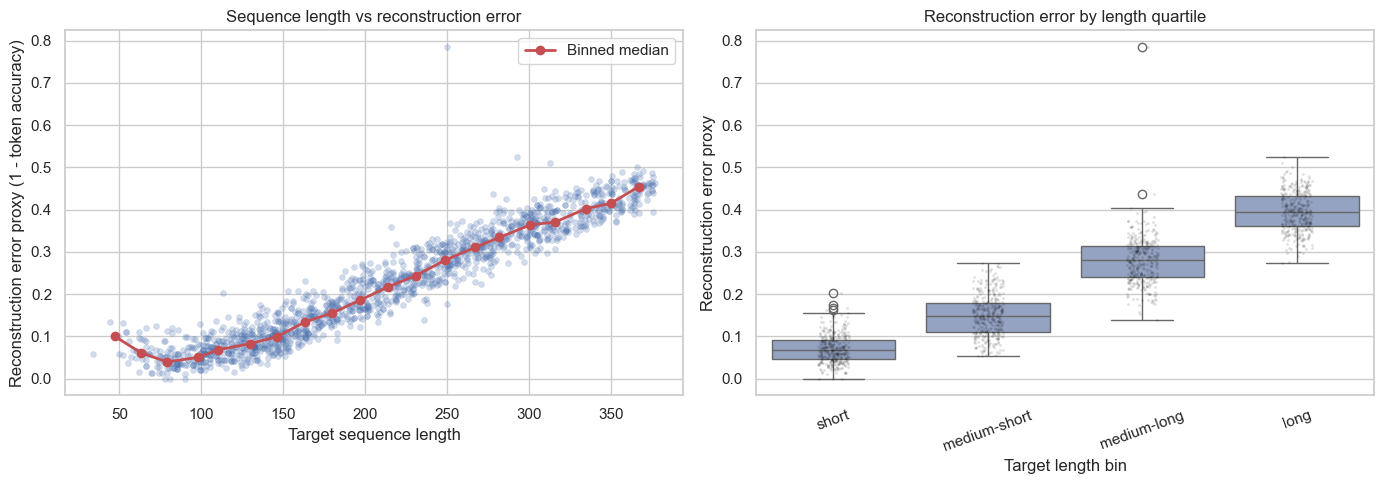

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=results,
    x="target_length",
    y="reconstruction_error",
    alpha=0.25,
    s=18,
    edgecolor=None,
    ax=axes[0],
)

trend = (
    results.assign(length_window=pd.cut(results["target_length"], bins=20))
    .groupby("length_window", observed=True)
    .agg(
        target_length=("target_length", "median"),
        reconstruction_error=("reconstruction_error", "median"),
    )
    .dropna()
)

axes[0].plot(
    trend["target_length"],
    trend["reconstruction_error"],
    color="#c44e52",
    linewidth=2,
    marker="o",
    label="Binned median",
)
axes[0].legend()
axes[0].set_title("Sequence length vs reconstruction error")
axes[0].set_xlabel("Target sequence length")
axes[0].set_ylabel("Reconstruction error proxy (1 - token accuracy)")

sns.boxplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="#8da0cb")
sns.stripplot(data=results, x="length_bin", y="reconstruction_error", ax=axes[1], color="black", alpha=0.12, size=2)
axes[1].set_title("Reconstruction error by length quartile")
axes[1].set_xlabel("Target length bin")
axes[1].set_ylabel("Reconstruction error proxy")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [4]:
spearman_r, spearman_p = stats.spearmanr(results["target_length"], results["reconstruction_error"])
pearson_r, pearson_p = stats.pearsonr(results["target_length"], results["reconstruction_error"])

groups = [g["reconstruction_error"].to_numpy() for _, g in results.groupby("length_bin", observed=True)]
kruskal_h, kruskal_p = stats.kruskal(*groups)

q1_stats = pd.DataFrame(
    [
        {"test": "Spearman length vs error", "statistic": spearman_r, "p_value": spearman_p},
        {"test": "Pearson length vs error", "statistic": pearson_r, "p_value": pearson_p},
        {"test": "Kruskal-Wallis error across length bins", "statistic": kruskal_h, "p_value": kruskal_p},
    ]
)
display(q1_stats)

alpha = 0.05
print(
    f"Spearman rho={spearman_r:.3f}, p={spearman_p:.3g}. "
    f"Length-bin Kruskal-Wallis p={kruskal_p:.3g}. "
    f"At alpha={alpha}, the length/error association is "
    f"{'statistically detectable' if spearman_p < alpha else 'not statistically detectable'} in this output file."
)

,test,statistic,p_value
0,Spearman length vs error,0.961589,0.000000e+00
1,Pearson length vs error,0.956778,0.000000e+00
2,Kruskal-Wallis error across length bins,1310.434846,8.010647e-284


Spearman rho=0.962, p=0. Length-bin Kruskal-Wallis p=8.01e-284. At alpha=0.05, the length/error association is statistically detectable in this output file.


## 2. Amino-Acid Specific Reconstruction Errors

This section compares each target amino acid to the predicted amino acid at the same decoder position. If the prediction ended early, remaining target positions are counted as incorrect. This matches the token-level reconstruction framing used by `test_autoencoder.py`.

In [5]:
aa_rows = []
confusion_rows = []

for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
        correct = target_aa == predicted_aa
        aa_rows.append({"target_aa": target_aa, "correct": correct, "position": pos, "example_index": row.example_index})
        confusion_rows.append({"target_aa": target_aa, "predicted_aa": predicted_aa})

aa_df = pd.DataFrame(aa_rows)
aa_summary = (
    aa_df.groupby("target_aa")
    .agg(n_tokens=("correct", "size"), n_incorrect=("correct", lambda s: (~s).sum()), accuracy=("correct", "mean"))
    .assign(error_rate=lambda d: 1.0 - d["accuracy"])
    .sort_values("error_rate", ascending=False)
)
display(aa_summary)

,n_tokens,n_incorrect,accuracy,error_rate
target_aa,,,,
A,25200,9828,0.610000,0.390000
L,29904,9687,0.676063,0.323937
R,17879,5633,0.684938,0.315062
E,22798,7008,0.692605,0.307395
S,20382,6256,0.693063,0.306937
G,20972,6274,0.700839,0.299161
K,18726,5365,0.713500,0.286500
V,20442,5847,0.713971,0.286029
I,18053,5157,0.714341,0.285659


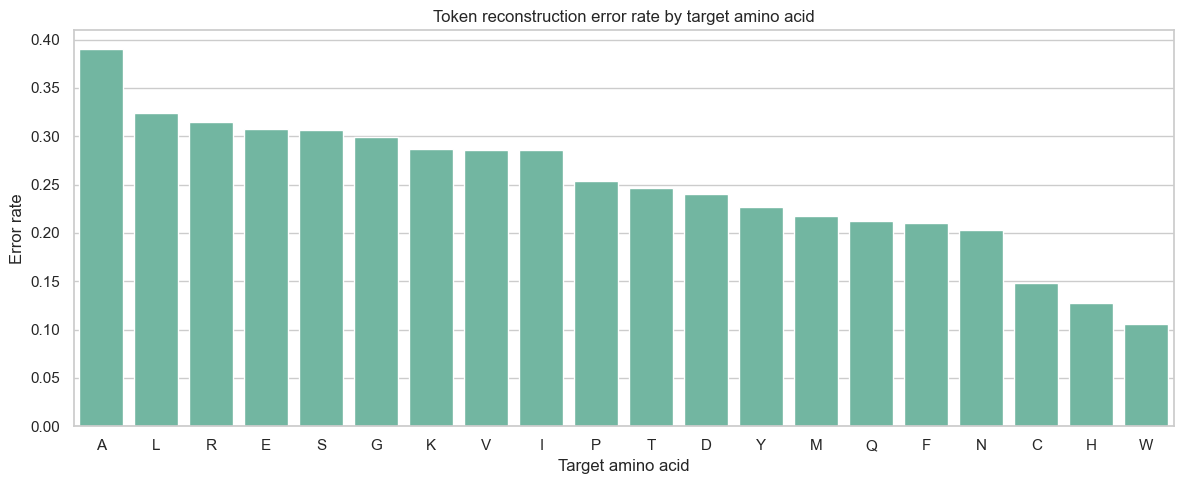

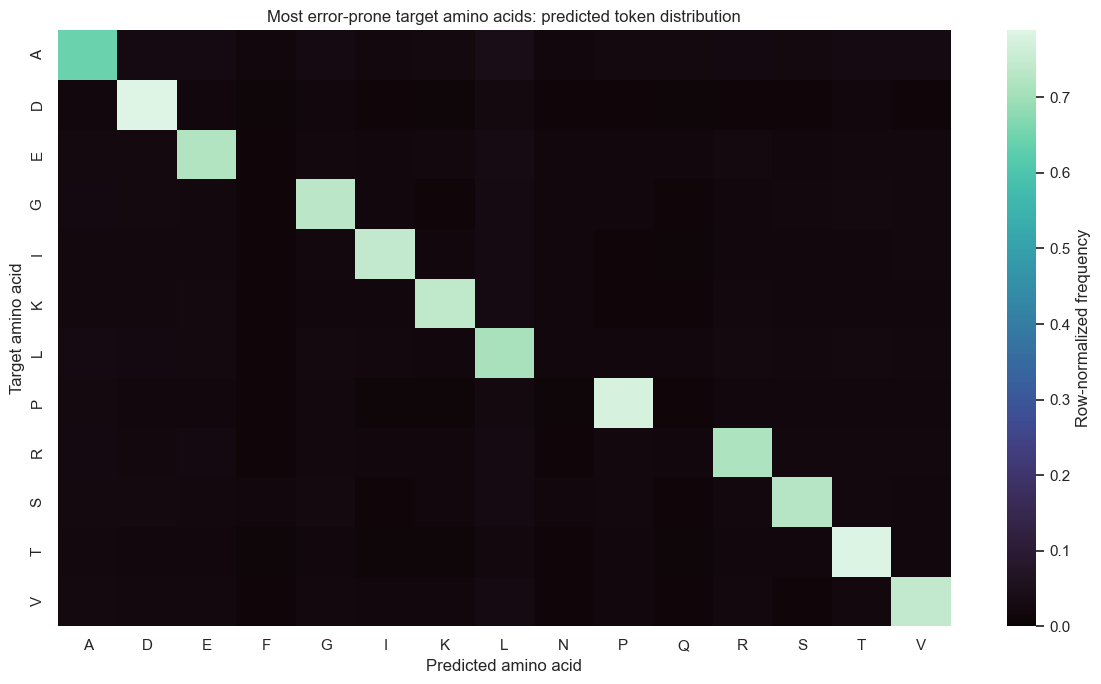

In [6]:
def plot_aa_error_rate(aa_summary, length_bin=None):
    plt.figure(figsize=(12, 5))
    plot_df = aa_summary.reset_index().sort_values("error_rate", ascending=False)
    sns.barplot(data=plot_df, x="target_aa", y="error_rate", color="#66c2a5")
    title = "Token reconstruction error rate by target amino acid"
    if length_bin:
        title += f" ({length_bin} sequences)"
    plt.title(title)
    plt.xlabel("Target amino acid")
    plt.ylabel("Error rate")
    plt.tight_layout()
    plt.show()

    top_targets = aa_summary.head(12).index.tolist()
    # top_targets = aa_summary.index.tolist()
    confusion_df = pd.DataFrame(confusion_rows)
    confusion_top = confusion_df[confusion_df["target_aa"].isin(top_targets)].copy()
    top_predictions = confusion_top["predicted_aa"].value_counts().head(15).index.tolist()
    confusion_top = confusion_top[confusion_top["predicted_aa"].isin(top_predictions)]
    confusion_matrix = pd.crosstab(confusion_top["target_aa"], confusion_top["predicted_aa"], normalize="index")

    plt.figure(figsize=(12, 7))
    sns.heatmap(confusion_matrix, cmap="mako", vmin=0, vmax=confusion_matrix.to_numpy().max(), cbar_kws={"label": "Row-normalized frequency"})
    plt.title("Most error-prone target amino acids: predicted token distribution")
    plt.xlabel("Predicted amino acid")
    plt.ylabel("Target amino acid")
    plt.tight_layout()
    plt.show()

plot_aa_error_rate(aa_summary)

In [7]:
def aa_error_stats(aa_df, aa_summary):
    contingency = pd.crosstab(aa_df["target_aa"], aa_df["correct"])
    chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)

    overall_error = 1.0 - aa_df["correct"].mean()
    aa_summary_for_tests = aa_summary.copy()
    aa_summary_for_tests["binom_p_value"] = [
        stats.binomtest(int(row.n_incorrect), int(row.n_tokens), overall_error, alternative="greater").pvalue
        for row in aa_summary_for_tests.itertuples()
    ]
    aa_summary_for_tests["bonferroni_p_value"] = np.minimum(aa_summary_for_tests["binom_p_value"] * len(aa_summary_for_tests), 1.0)

    print(f"Chi-square test of amino acid vs correctness: chi2={chi2:.2f}, dof={dof}, p={chi2_p:.3g}")
    print(f"Overall token error rate from aligned target positions: {overall_error:.3f}")
    display(aa_summary_for_tests.sort_values("bonferroni_p_value").head(10))
    
aa_error_stats(aa_df, aa_summary)

Chi-square test of amino acid vs correctness: chi2=5937.97, dof=19, p=0
Overall token error rate from aligned target positions: 0.275


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
A,25200,9828,0.610000,0.390000,0.000000e+00,0.000000e+00
L,29904,9687,0.676063,0.323937,4.135717e-79,8.271434e-78
R,17879,5633,0.684938,0.315062,3.237830e-33,6.475659e-32
E,22798,7008,0.692605,0.307395,2.769855e-28,5.539709e-27
S,20382,6256,0.693063,0.306937,7.644711e-25,1.528942e-23
G,20972,6274,0.700839,0.299161,1.409784e-15,2.819568e-14
V,20442,5847,0.713971,0.286029,1.336513e-04,2.673027e-03
K,18726,5365,0.713500,0.286500,1.409240e-04,2.818481e-03
I,18053,5157,0.714341,0.285659,4.595062e-04,9.190124e-03


## 2B. Amino Acid Error Rate by Length Bucket

This section looks at the quartiles of the sequence lengths, and evaluates the amino acid error rates within each quartile. The idea is to see if we can identify what about long sequences is failing.

In [8]:
# output_results.csv does not include cross-entropy loss, so this is a token-error proxy.
results["reconstruction_error"] = 1.0 - results["token_accuracy"]
results["length_delta"] = results["predicted_length"] - results["target_length"]
results["abs_length_delta"] = results["length_delta"].abs()
results["length_bin"] = pd.qcut(
    results["target_length"],
    q=4,
    labels=["short", "medium-short", "medium-long", "long"],
    duplicates="drop",
)

short_bin = results[results["length_bin"] == "short"]
medium_short_bin = results[results["length_bin"] == "medium-short"]
medium_long_bin = results[results["length_bin"] == "medium-long"]
long_bin = results[results["length_bin"] == "long"]

In [9]:
def aa_summary_by_bin(bin: pd.DataFrame, bin_name: str):
    aa_rows = []
    confusion_rows = []

    for row in bin.itertuples(index=False):
        target = str(row.target_sequence)
        predicted = str(row.predicted_sequence)
        for pos, target_aa in enumerate(target):
            predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
            correct = target_aa == predicted_aa
            aa_rows.append({"target_aa": target_aa, "correct": correct, "position": pos, "example_index": row.example_index})
            confusion_rows.append({"target_aa": target_aa, "predicted_aa": predicted_aa})

    aa_df = pd.DataFrame(aa_rows)
    aa_summary = (
        aa_df.groupby("target_aa")
        .agg(n_tokens=("correct", "size"), n_incorrect=("correct", lambda s: (~s).sum()), accuracy=("correct", "mean"))
        .assign(error_rate=lambda d: 1.0 - d["accuracy"])
        .sort_values("error_rate", ascending=False)
    )
    return aa_df, aa_summary
    

aa_short_bin_df, aa_short_bin_summary = aa_summary_by_bin(short_bin, "short")
aa_medium_short_bin_df, aa_medium_short_bin_summary = aa_summary_by_bin(medium_short_bin, "medium-short")
aa_medium_long_bin_df, aa_medium_long_bin_summary = aa_summary_by_bin(medium_long_bin, "medium-long")
aa_long_bin_df, aa_long_bin_summary = aa_summary_by_bin(long_bin, "long")

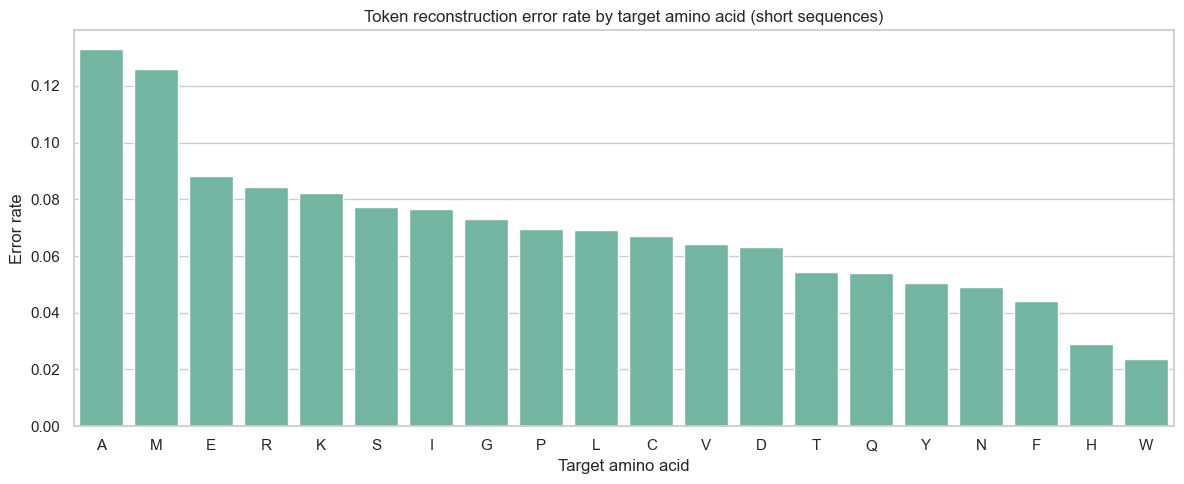

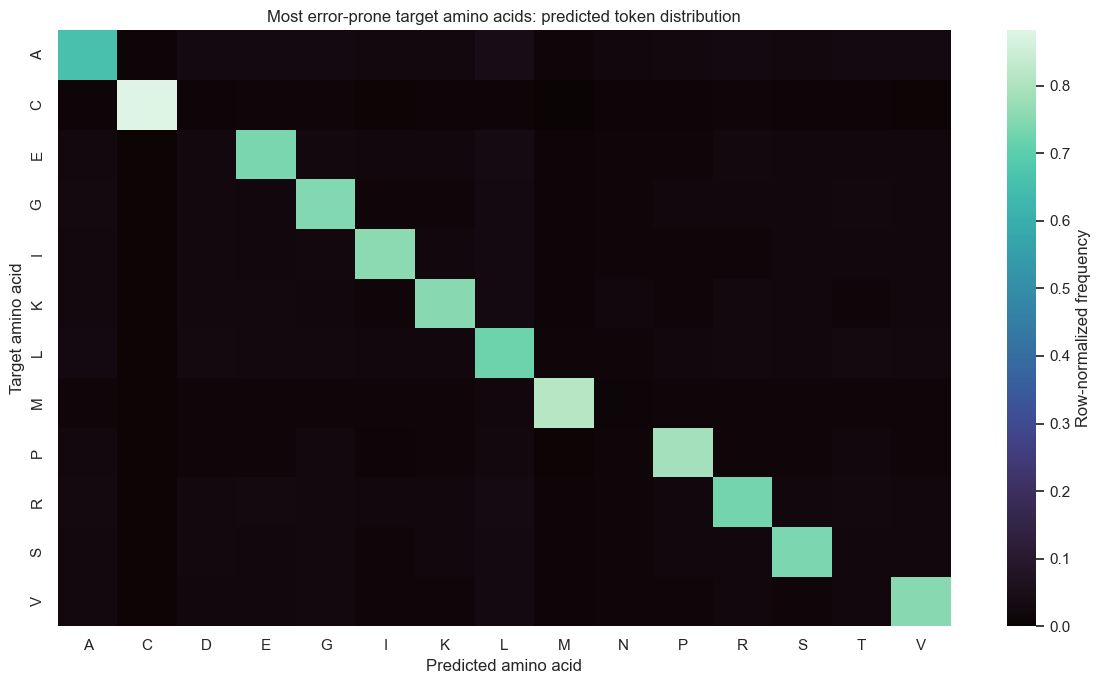

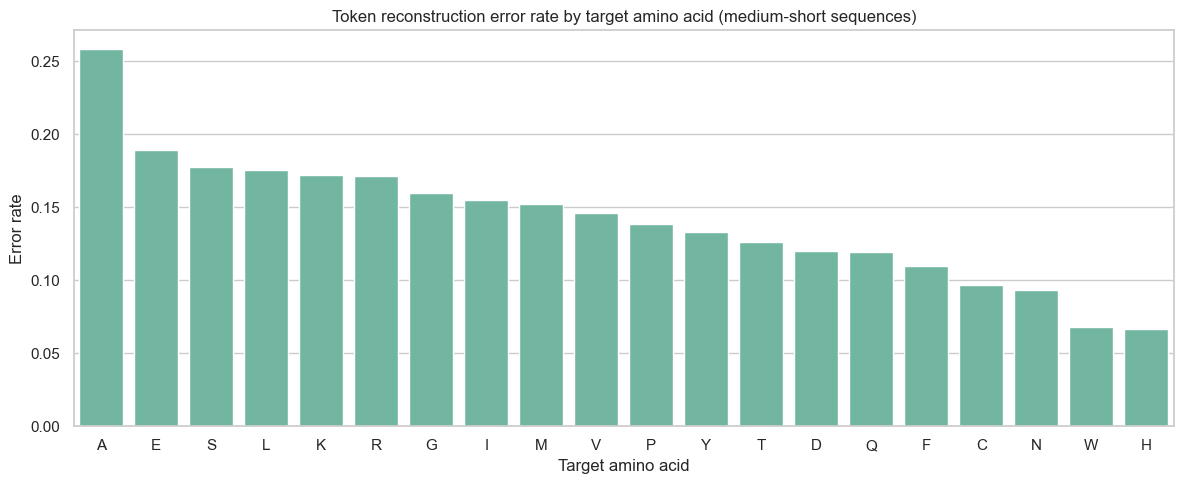

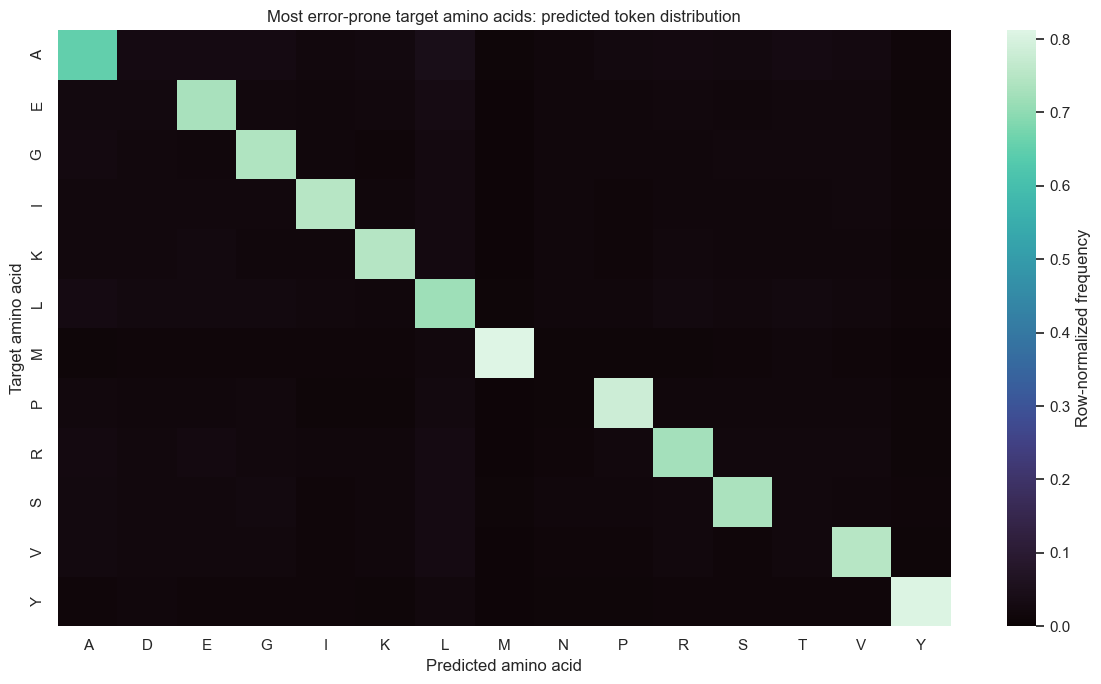

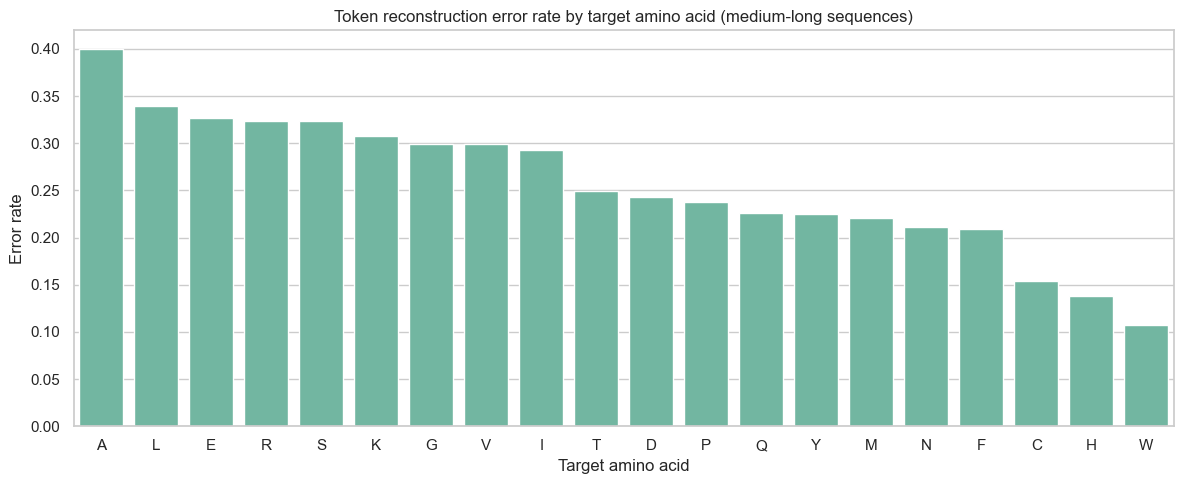

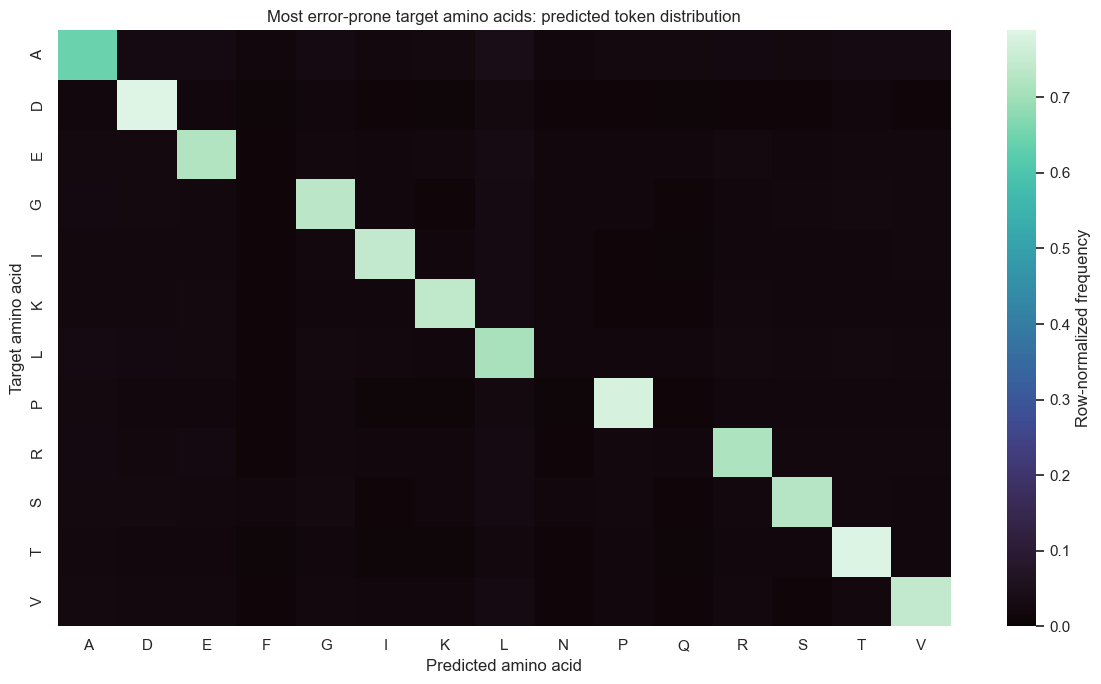

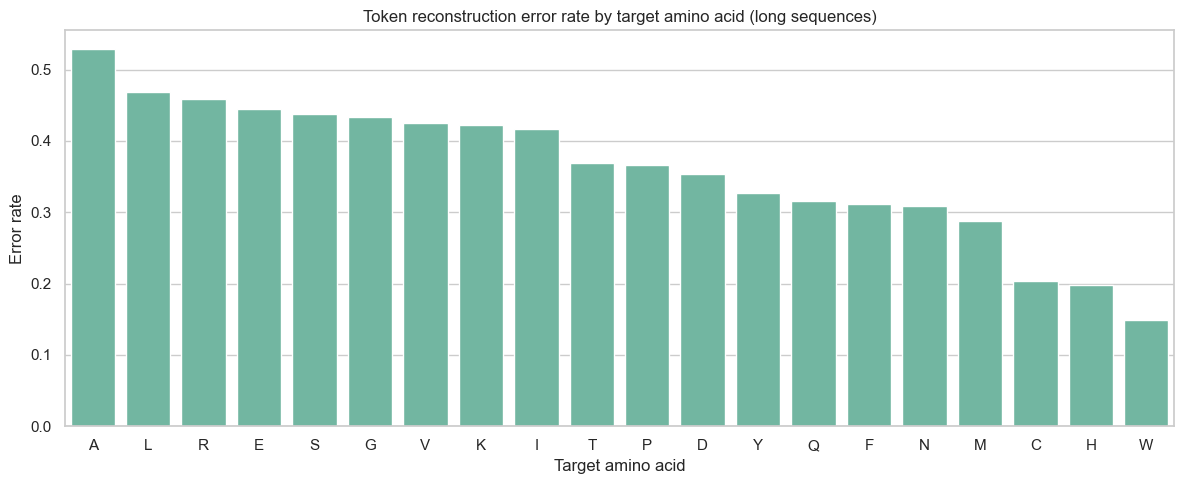

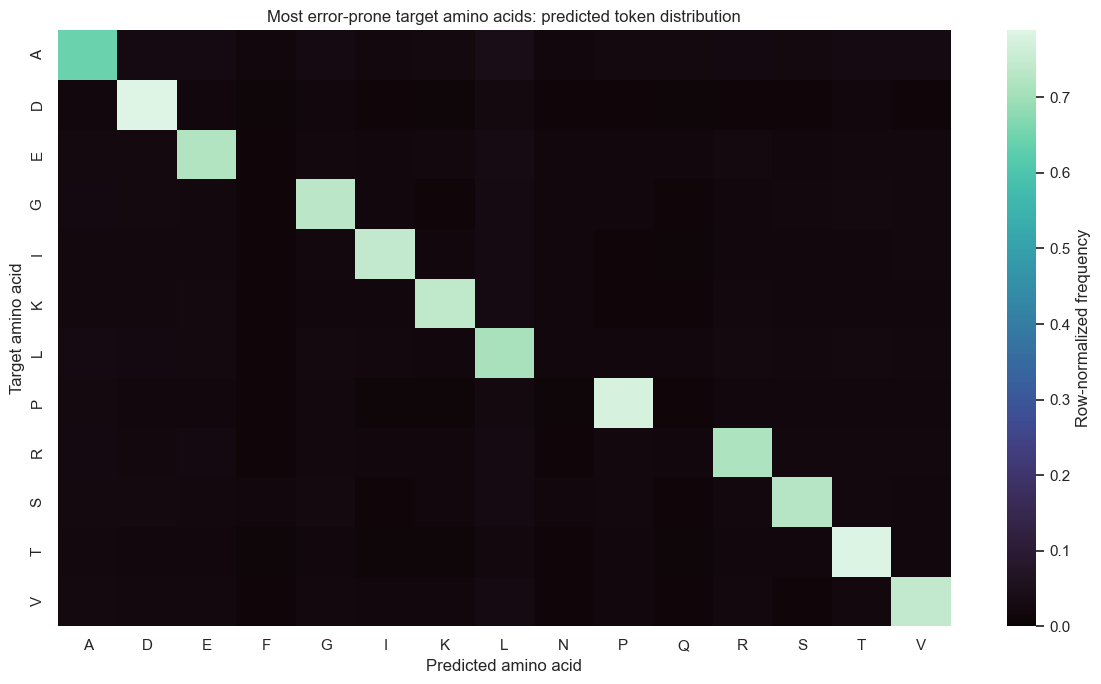

In [10]:
plot_aa_error_rate(aa_short_bin_summary, "short")
plot_aa_error_rate(aa_medium_short_bin_summary, "medium-short")
plot_aa_error_rate(aa_medium_long_bin_summary, "medium-long")
plot_aa_error_rate(aa_long_bin_summary, "long")

In [11]:
aa_error_stats(aa_short_bin_df, aa_short_bin_summary)
aa_error_stats(aa_medium_short_bin_df, aa_medium_short_bin_summary)
aa_error_stats(aa_medium_long_bin_df, aa_medium_long_bin_summary)
aa_error_stats(aa_long_bin_df, aa_long_bin_summary)

Chi-square test of amino acid vs correctness: chi2=352.87, dof=19, p=2.6e-63
Overall token error rate from aligned target positions: 0.074


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
A,3002,399,0.867089,0.132911,9.485687e-30,1.897137e-28
M,1143,144,0.874016,0.125984,3.253717e-10,6.507434e-09
E,3195,282,0.911737,0.088263,1.065500e-03,2.131000e-02
R,2301,194,0.915689,0.084311,2.825235e-02,5.650470e-01
F,1381,61,0.955829,0.044171,9.999972e-01,1.000000e+00
N,1673,82,0.950986,0.049014,9.999807e-01,1.000000e+00
Y,1224,62,0.949346,0.050654,9.994892e-01,1.000000e+00
Q,1688,91,0.946090,0.053910,9.994682e-01,1.000000e+00
T,2037,111,0.945508,0.054492,9.997474e-01,1.000000e+00


Chi-square test of amino acid vs correctness: chi2=939.80, dof=19, p=3.71e-187
Overall token error rate from aligned target positions: 0.155


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
A,5098,1317,0.741663,0.258337,3.147203e-80,6.294407e-79
E,4932,935,0.810422,0.189578,3.916525e-11,7.833049e-10
L,6029,1058,0.824515,0.175485,8.535966e-06,1.707193e-04
S,4160,738,0.822596,0.177404,4.865688e-05,9.731376e-04
K,4045,697,0.827689,0.172311,1.459253e-03,2.918506e-02
R,3523,603,0.828839,0.171161,4.774824e-03,9.549648e-02
N,2585,241,0.906770,0.093230,1.000000e+00,1.000000e+00
C,794,77,0.903023,0.096977,9.999994e-01,1.000000e+00
F,2481,273,0.889964,0.110036,1.000000e+00,1.000000e+00


Chi-square test of amino acid vs correctness: chi2=1862.80, dof=19, p=0
Overall token error rate from aligned target positions: 0.283


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
A,7177,2868,0.600390,0.399610,1.122802e-99,2.245604e-98
L,8810,2992,0.660386,0.339614,4.139678e-31,8.279356e-30
E,6281,2055,0.672823,0.327177,1.265877e-14,2.531753e-13
S,6043,1956,0.676320,0.323680,2.855804e-12,5.711608e-11
R,5120,1659,0.675977,0.324023,8.290556e-11,1.658111e-09
K,5434,1671,0.692492,0.307508,4.101378e-05,8.202756e-04
G,6023,1804,0.700481,0.299519,2.634923e-03,5.269846e-02
V,5851,1748,0.701248,0.298752,4.384813e-03,8.769627e-02
C,1152,177,0.846354,0.153646,1.000000e+00,1.000000e+00


Chi-square test of amino acid vs correctness: chi2=3338.72, dof=19, p=0
Overall token error rate from aligned target positions: 0.398


,n_tokens,n_incorrect,accuracy,error_rate,binom_p_value,bonferroni_p_value
target_aa,,,,,,
A,9923,5244,0.471531,0.528469,1.130953e-150,2.261906e-149
L,11497,5390,0.531182,0.468818,5.794937e-53,1.158987e-51
R,6935,3177,0.541889,0.458111,4.112514e-24,8.225028e-23
E,8390,3736,0.554708,0.445292,1.685142e-18,3.370283e-17
S,7704,3371,0.562435,0.437565,1.668528e-12,3.337055e-11
G,8394,3637,0.566714,0.433286,4.737661e-11,9.475322e-10
V,7823,3322,0.575355,0.424645,1.294243e-06,2.588486e-05
K,6568,2777,0.577192,0.422808,3.122803e-05,6.245606e-04
I,6899,2877,0.582983,0.417017,8.843270e-04,1.768654e-02


## 3. Position-Wise Reconstruction Errors

This analysis checks whether the decoder gets worse as it moves through a sequence. Absolute position shows whether errors grow at large token indices. Relative position shows whether errors are concentrated near the beginning, middle, or end of proteins regardless of their total length.

In [12]:
position_rows = []

for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    target_len = len(target)
    if target_len == 0:
        continue

    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
        position_rows.append(
            {
                "example_index": row.example_index,
                "absolute_position": pos + 1,
                "relative_position": (pos + 1) / target_len,
                "target_length": target_len,
                "length_bin": row.length_bin,
                "target_aa": target_aa,
                "predicted_aa": predicted_aa,
                "correct": target_aa == predicted_aa,
                "error": int(target_aa != predicted_aa),
            }
        )

position_df = pd.DataFrame(position_rows)
position_df["absolute_position_bin"] = pd.cut(position_df["absolute_position"], bins=40)
position_df["relative_position_bin"] = pd.cut(
    position_df["relative_position"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

absolute_position_summary = (
    position_df.groupby("absolute_position_bin", observed=True)
    .agg(
        position_midpoint=("absolute_position", "median"),
        n_tokens=("error", "size"),
        error_rate=("error", "mean"),
    )
    .query("n_tokens >= 50")
    .reset_index(drop=True)
)

relative_position_summary = (
    position_df.groupby(["relative_position_bin", "length_bin"], observed=True)
    .agg(
        relative_position_midpoint=("relative_position", "median"),
        n_tokens=("error", "size"),
        error_rate=("error", "mean"),
    )
    .reset_index()
)

display(absolute_position_summary.head())
display(relative_position_summary.head())

,position_midpoint,n_tokens,error_rate
0,5.5,14930,0.070395
1,15.0,13437,0.191635
2,24.5,14930,0.227662
3,34.0,13433,0.214025
4,43.0,14915,0.207241


,relative_position_bin,length_bin,relative_position_midpoint,n_tokens,error_rate
0,"(-0.001, 0.1]",long,0.050898,11977,0.239709
1,"(-0.001, 0.1]",medium-long,0.051095,9021,0.183239
2,"(-0.001, 0.1]",medium-short,0.051669,6324,0.117015
3,"(-0.001, 0.1]",short,0.052632,3842,0.072098
4,"(0.1, 0.2]",long,0.150289,12158,0.367495


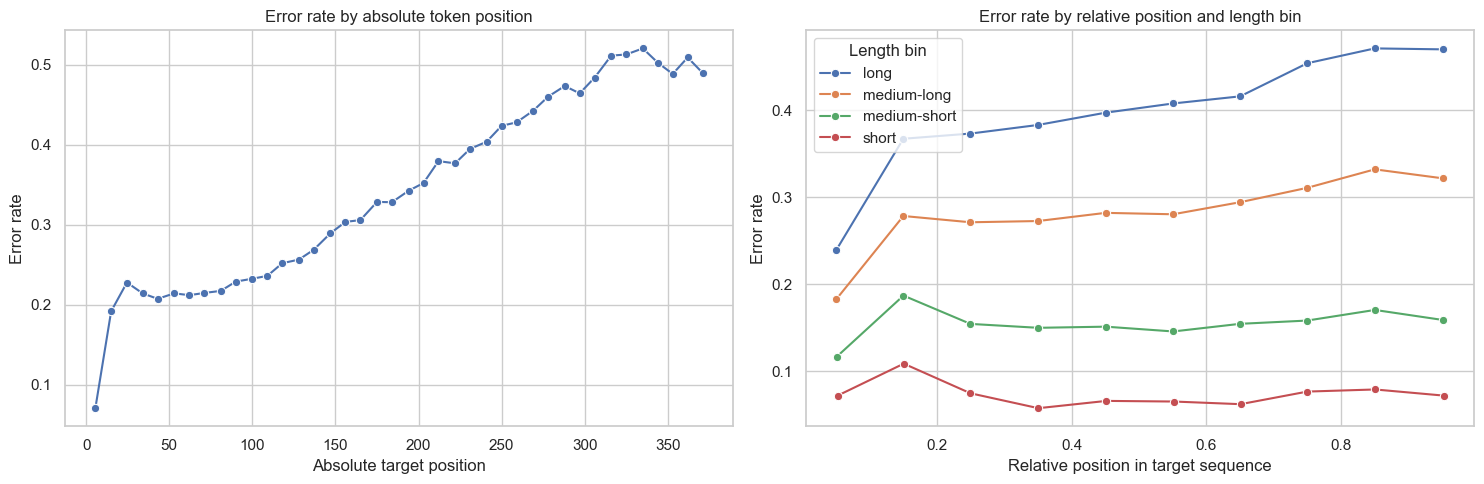

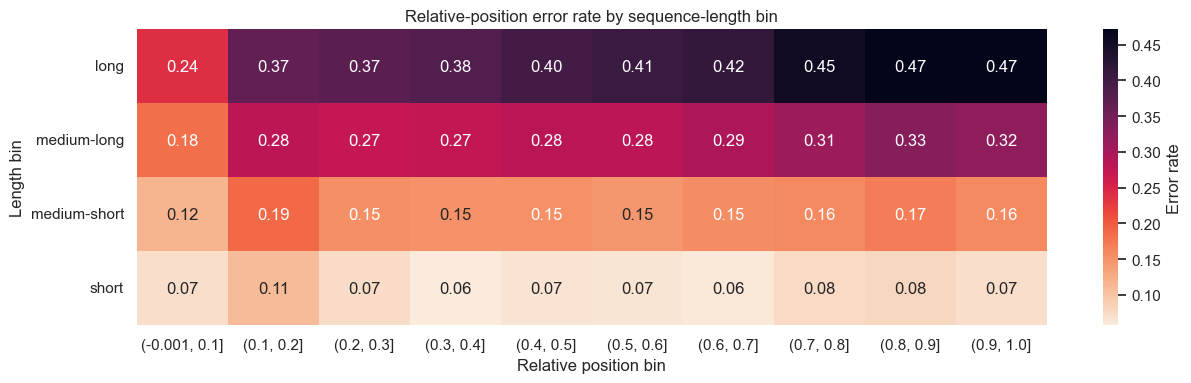

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(
    data=absolute_position_summary,
    x="position_midpoint",
    y="error_rate",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Error rate by absolute token position")
axes[0].set_xlabel("Absolute target position")
axes[0].set_ylabel("Error rate")

sns.lineplot(
    data=relative_position_summary,
    x="relative_position_midpoint",
    y="error_rate",
    hue="length_bin",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Error rate by relative position and length bin")
axes[1].set_xlabel("Relative position in target sequence")
axes[1].set_ylabel("Error rate")
axes[1].legend(title="Length bin")

plt.tight_layout()
plt.show()

position_heatmap = relative_position_summary.pivot(
    index="length_bin",
    columns="relative_position_bin",
    values="error_rate",
)

plt.figure(figsize=(13, 4))
sns.heatmap(position_heatmap, cmap="rocket_r", annot=True, fmt=".2f", cbar_kws={"label": "Error rate"})
plt.title("Relative-position error rate by sequence-length bin")
plt.xlabel("Relative position bin")
plt.ylabel("Length bin")
plt.tight_layout()
plt.show()

In [14]:
abs_pos_rho, abs_pos_p = stats.spearmanr(position_df["absolute_position"], position_df["error"])
rel_pos_rho, rel_pos_p = stats.spearmanr(position_df["relative_position"], position_df["error"])

relative_groups = [
    group["error"].to_numpy()
    for _, group in position_df.groupby("relative_position_bin", observed=True)
]
rel_kruskal_h, rel_kruskal_p = stats.kruskal(*relative_groups)

position_tests = pd.DataFrame(
    [
        {"test": "Spearman absolute position vs error", "statistic": abs_pos_rho, "p_value": abs_pos_p},
        {"test": "Spearman relative position vs error", "statistic": rel_pos_rho, "p_value": rel_pos_p},
        {"test": "Kruskal-Wallis error across relative-position bins", "statistic": rel_kruskal_h, "p_value": rel_kruskal_p},
    ]
)
display(position_tests)

print(
    f"Absolute-position Spearman rho={abs_pos_rho:.3f}, p={abs_pos_p:.3g}. "
    f"Relative-position Spearman rho={rel_pos_rho:.3f}, p={rel_pos_p:.3g}."
)

,test,statistic,p_value
0,Spearman absolute position vs error,0.196830,0.0
1,Spearman relative position vs error,0.071931,0.0
2,Kruskal-Wallis error across relative-position ...,2248.696684,0.0


Absolute-position Spearman rho=0.197, p=0. Relative-position Spearman rho=0.072, p=0.


## 4. Length and EOS-Style Failure Analysis

`output_results.csv` stores decoded string lengths, not explicit EOS probabilities. Still, predicted length vs target length is a useful proxy for EOS/stop behavior. If high-error examples also have large length errors, the model may be struggling with when to stop rather than only which amino acid to emit.

In [15]:
length_error_df = results.copy()
length_error_df["length_error_type"] = np.select(
    [
        length_error_df["length_delta"] < 0,
        length_error_df["length_delta"] == 0,
        length_error_df["length_delta"] > 0,
    ],
    ["shorter_than_target", "exact_length", "longer_than_target"],
    default="unknown",
)

length_error_df["large_length_error"] = (
    length_error_df["abs_length_delta"] >= 0.10 * length_error_df["target_length"]
)

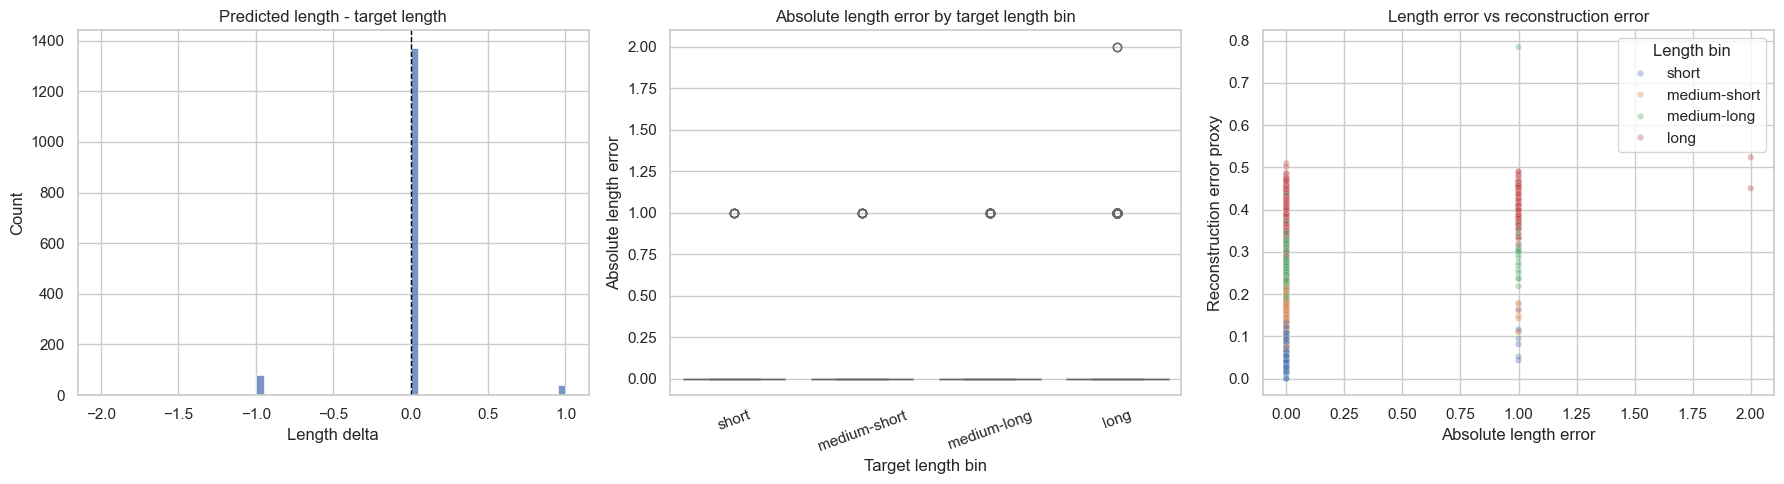

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=length_error_df, x="length_delta", bins=60, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Predicted length - target length")
axes[0].set_xlabel("Length delta")

sns.boxplot(data=length_error_df, x="length_bin", y="abs_length_delta", ax=axes[1], color="#fc8d62")
axes[1].set_title("Absolute length error by target length bin")
axes[1].set_xlabel("Target length bin")
axes[1].set_ylabel("Absolute length error")
axes[1].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=length_error_df,
    x="abs_length_delta",
    y="reconstruction_error",
    hue="length_bin",
    alpha=0.35,
    s=22,
    ax=axes[2],
)
axes[2].set_title("Length error vs reconstruction error")
axes[2].set_xlabel("Absolute length error")
axes[2].set_ylabel("Reconstruction error proxy")
axes[2].legend(title="Length bin")

plt.tight_layout()
plt.show()

In [17]:
length_delta_rho, length_delta_p = stats.spearmanr(length_error_df["target_length"], length_error_df["length_delta"])
abs_length_error_rho, abs_length_error_p = stats.spearmanr(length_error_df["abs_length_delta"], length_error_df["reconstruction_error"])

length_type_groups = [
    group["reconstruction_error"].to_numpy()
    for _, group in length_error_df.groupby("length_error_type", observed=True)
]
length_type_h, length_type_p = stats.kruskal(*length_type_groups)

length_tests = pd.DataFrame(
    [
        {"test": "Spearman target length vs length delta", "statistic": length_delta_rho, "p_value": length_delta_p},
        {"test": "Spearman absolute length error vs reconstruction error", "statistic": abs_length_error_rho, "p_value": abs_length_error_p},
        {"test": "Kruskal-Wallis reconstruction error across length-error types", "statistic": length_type_h, "p_value": length_type_p},
    ]
)
display(length_tests)

print(
    f"Abs length error vs reconstruction error: rho={abs_length_error_rho:.3f}, p={abs_length_error_p:.3g}. "
    "A strong positive value means length-control failures explain a meaningful part of the reconstruction problem."
)

,test,statistic,p_value
0,Spearman target length vs length delta,-0.100018,1.083398e-04
1,Spearman absolute length error vs reconstructi...,0.305808,1.091432e-33
2,Kruskal-Wallis reconstruction error across len...,139.314544,5.600555e-31


Abs length error vs reconstruction error: rho=0.306, p=1.09e-33. A strong positive value means length-control failures explain a meaningful part of the reconstruction problem.


## 5. High-Rate Amino-Acid Confusions

This section asks which target amino acids are most often decoded as specific other amino acids. The heatmap is row-normalized by target amino acid, so each value means: among all true tokens of this amino acid, what fraction were decoded as the column amino acid? The table below focuses on off-diagonal mistakes only.

In [18]:
standard_aas = list("ACDEFGHIKLMNPQRSTVWY")

if "aa_df" not in globals() or "predicted_aa" not in aa_df.columns:
    aa_rows = []
    for row in results.itertuples(index=False):
        target = str(row.target_sequence)
        predicted = str(row.predicted_sequence)
        for pos, target_aa in enumerate(target):
            predicted_aa = predicted[pos] if pos < len(predicted) else "<END>"
            aa_rows.append(
                {
                    "target_aa": target_aa,
                    "predicted_aa": predicted_aa,
                    "correct": target_aa == predicted_aa,
                }
            )
    aa_df = pd.DataFrame(aa_rows)

aa_confusions = aa_df[aa_df["target_aa"].isin(standard_aas)].copy()
target_counts = aa_confusions["target_aa"].value_counts().rename("target_count")
incorrect_counts = (
    aa_confusions[aa_confusions["target_aa"] != aa_confusions["predicted_aa"]]
    .groupby("target_aa")
    .size()
    .rename("target_error_count")
)

pair_counts = (
    aa_confusions[aa_confusions["target_aa"] != aa_confusions["predicted_aa"]]
    .groupby(["target_aa", "predicted_aa"])
    .size()
    .rename("n_confusions")
    .reset_index()
    .merge(target_counts, left_on="target_aa", right_index=True)
    .merge(incorrect_counts, left_on="target_aa", right_index=True)
)
pair_counts["rate_among_target_tokens"] = pair_counts["n_confusions"] / pair_counts["target_count"]
pair_counts["share_of_target_errors"] = pair_counts["n_confusions"] / pair_counts["target_error_count"]
pair_counts["confusion_pair"] = pair_counts["target_aa"] + " -> " + pair_counts["predicted_aa"]

aa_pair_counts = pair_counts[pair_counts["predicted_aa"].isin(standard_aas)].copy()
top_confusion_pairs = aa_pair_counts.sort_values(
    ["rate_among_target_tokens", "n_confusions"],
    ascending=False,
).head(25)

display(top_confusion_pairs[[
    "confusion_pair",
    "n_confusions",
    "target_count",
    "target_error_count",
    "rate_among_target_tokens",
    "share_of_target_errors",
]])

,confusion_pair,n_confusions,target_count,target_error_count,rate_among_target_tokens,share_of_target_errors
9,A -> L,994,25200,9828,0.039444,0.101140
69,E -> L,688,22798,7008,0.030178,0.098174
286,R -> L,524,17879,5633,0.029308,0.093023
346,V -> L,575,20442,5847,0.028128,0.098341
2,A -> D,695,25200,9828,0.027579,0.070716
5,A -> G,693,25200,9828,0.027500,0.070513
179,L -> A,820,29904,9687,0.027421,0.084650
16,A -> T,688,25200,9828,0.027302,0.070004
3,A -> E,685,25200,9828,0.027183,0.069699
167,K -> L,507,18726,5365,0.027075,0.094501


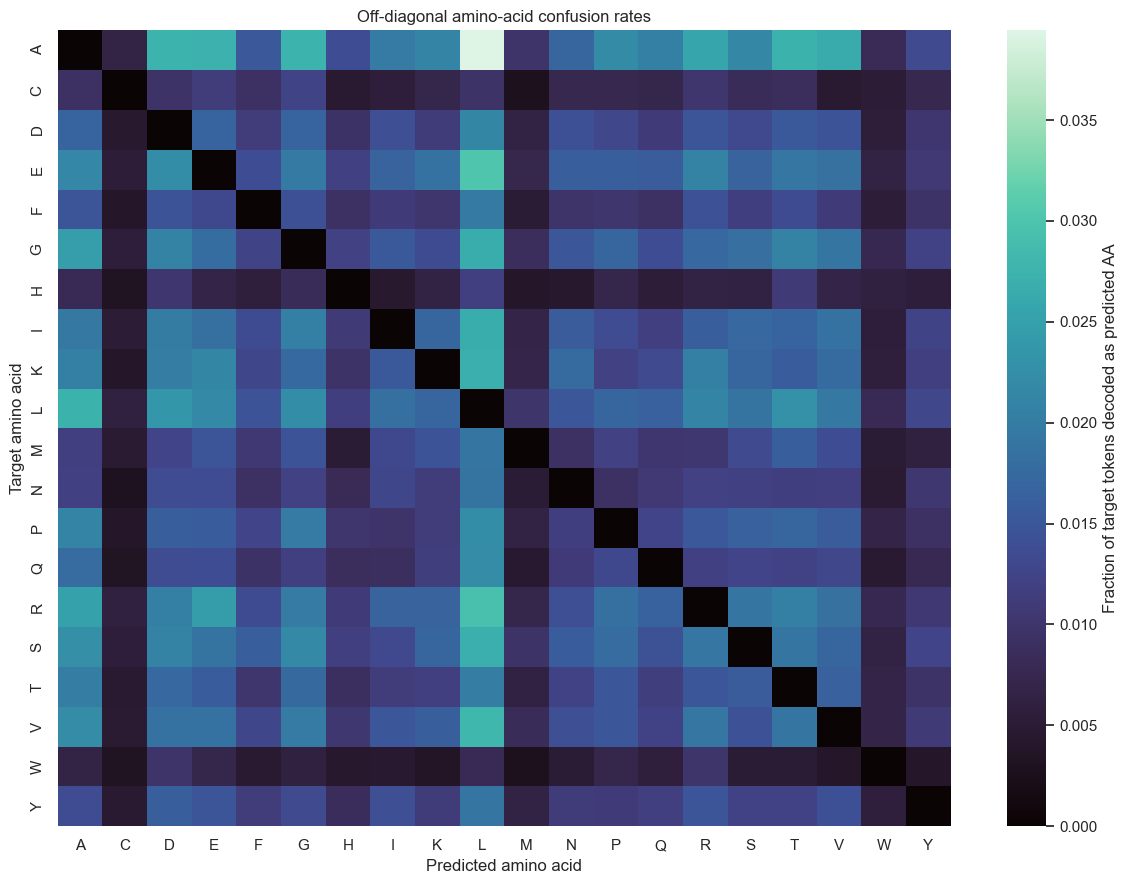

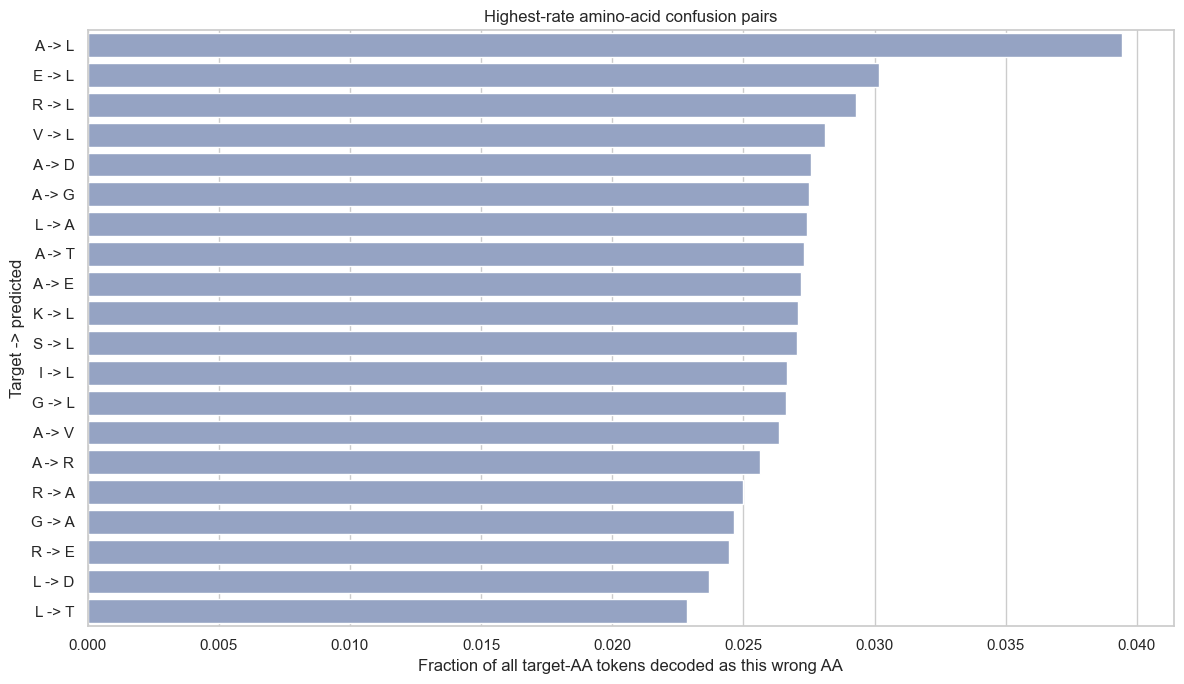

In [19]:
confusion_rate_matrix = pd.crosstab(
    aa_confusions["target_aa"],
    aa_confusions["predicted_aa"],
    normalize="index",
)
confusion_rate_matrix = confusion_rate_matrix.reindex(index=standard_aas, columns=standard_aas).fillna(0.0)

off_diagonal_matrix = confusion_rate_matrix.copy()
for aa in standard_aas:
    off_diagonal_matrix.loc[aa, aa] = 0.0

plt.figure(figsize=(12, 9))
sns.heatmap(
    off_diagonal_matrix,
    cmap="mako",
    vmin=0,
    cbar_kws={"label": "Fraction of target tokens decoded as predicted AA"},
)
plt.title("Off-diagonal amino-acid confusion rates")
plt.xlabel("Predicted amino acid")
plt.ylabel("Target amino acid")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_confusion_pairs.head(20),
    y="confusion_pair",
    x="rate_among_target_tokens",
    color="#8da0cb",
)
plt.title("Highest-rate amino-acid confusion pairs")
plt.xlabel("Fraction of all target-AA tokens decoded as this wrong AA")
plt.ylabel("Target -> predicted")
plt.tight_layout()
plt.show()

In [20]:
top_error_share_pairs = aa_pair_counts.sort_values(
    ["share_of_target_errors", "n_confusions"],
    ascending=False,
).head(25)

display(top_error_share_pairs[[
    "confusion_pair",
    "n_confusions",
    "target_count",
    "target_error_count",
    "rate_among_target_tokens",
    "share_of_target_errors",
]])

print(
    "Use rate_among_target_tokens to find high absolute-rate confusions. "
    "Use share_of_target_errors to see which wrong prediction dominates a target amino acid's mistakes."
)

,confusion_pair,n_confusions,target_count,target_error_count,rate_among_target_tokens,share_of_target_errors
266,Q -> L,272,12282,2602,0.022146,0.104535
9,A -> L,994,25200,9828,0.039444,0.101140
346,V -> L,575,20442,5847,0.028128,0.098341
69,E -> L,688,22798,7008,0.030178,0.098174
167,K -> L,507,18726,5365,0.027075,0.094501
370,W -> R,38,3803,403,0.009992,0.094293
88,F -> L,239,12119,2549,0.019721,0.093762
227,N -> L,242,12798,2592,0.018909,0.093364
147,I -> L,481,18053,5157,0.026644,0.093271
286,R -> L,524,17879,5633,0.029308,0.093023


Use rate_among_target_tokens to find high absolute-rate confusions. Use share_of_target_errors to see which wrong prediction dominates a target amino acid's mistakes.


## 6. Training History Curves

These curves compare checkpoint training histories. They are useful for checking whether a run is still improving, overfitting, diverging, or simply worse because the objective changed. The table reports the best validation-loss epoch for each history file.

In [21]:
history_records = []

for history_path in sorted(HISTORY_DIR.glob("**/*.json")):
    try:
        history = json.loads(history_path.read_text())
    except json.JSONDecodeError:
        continue

    history_name = str(history_path.relative_to(PROJECT_ROOT))
    hparams = history.get("hyperparameters", {})
    curriculum = history.get("curriculum", {})

    for epoch_record in history.get("epochs", []):
        history_records.append(
            {
                "history": history_name,
                "epoch": epoch_record.get("epoch"),
                "train_loss": epoch_record.get("train_loss"),
                "val_loss": epoch_record.get("val_loss"),
                "train_accuracy": epoch_record.get("train_accuracy"),
                "train_f1": epoch_record.get("train_f1"),
                "val_accuracy": epoch_record.get("val_accuracy"),
                "curriculum_fraction": epoch_record.get("curriculum_fraction"),
                "curriculum_examples": epoch_record.get("curriculum_examples"),
                "condition_decoder_on_latent": hparams.get("condition_decoder_on_latent"),
                "grad_clip": hparams.get("grad_clip"),
                "curriculum_type": curriculum.get("type", "unknown"),
            }
        )

history_df = pd.DataFrame(history_records)
history_df = history_df.replace([np.inf, -np.inf], np.nan)
numeric_history_cols = ["epoch", "train_loss", "val_loss", "train_accuracy", "train_f1", "val_accuracy"]
history_df[numeric_history_cols] = history_df[numeric_history_cols].apply(pd.to_numeric, errors="coerce")

solubility_ae_histories = [
    "history/solubility_ae_history.json",
    "history/v1/ae_v1_history.json",
    "history/v2/solubility_ae_history.json",
    "history/v3/solubility_ae_history.json",
    "history/v4/solubility_ae_history.json",
    "history/v5/solubility_ae_history.json",
]
plot_history_df = history_df[history_df["history"].isin(solubility_ae_histories)].copy()
plot_history_df = plot_history_df.dropna(subset=["epoch"])

best_history_rows = []
for history_name, group in plot_history_df.dropna(subset=["val_loss"]).groupby("history"):
    best = group.loc[group["val_loss"].idxmin()]
    last = group.sort_values("epoch").iloc[-1]
    best_history_rows.append(
        {
            "history": history_name,
            "n_epochs": int(group["epoch"].max()),
            "best_epoch": int(best["epoch"]),
            "best_val_loss": best["val_loss"],
            "best_val_accuracy": best["val_accuracy"],
            "last_epoch": int(last["epoch"]),
            "last_val_loss": last["val_loss"],
            "last_val_accuracy": last["val_accuracy"],
            "condition_decoder_on_latent": last["condition_decoder_on_latent"],
            "curriculum_type": last["curriculum_type"],
        }
    )

best_history_df = pd.DataFrame(best_history_rows).sort_values("history")
display(best_history_df)

,history,n_epochs,best_epoch,best_val_loss,best_val_accuracy,last_epoch,last_val_loss,last_val_accuracy,condition_decoder_on_latent,curriculum_type
0,history/v1/ae_v1_history.json,26,21,2.324400,0.265400,26,2.327000,0.263800,None,unknown
1,history/v2/solubility_ae_history.json,18,17,2.165478,0.303989,18,2.905450,0.094193,None,unknown
2,history/v3/solubility_ae_history.json,11,11,2.222754,0.284793,11,2.222754,0.284793,None,unknown
3,history/v4/solubility_ae_history.json,34,32,1.625085,0.406256,34,9.642488,0.058011,True,length
4,history/v5/solubility_ae_history.json,100,100,1.050459,0.596226,100,1.050459,0.596226,True,length


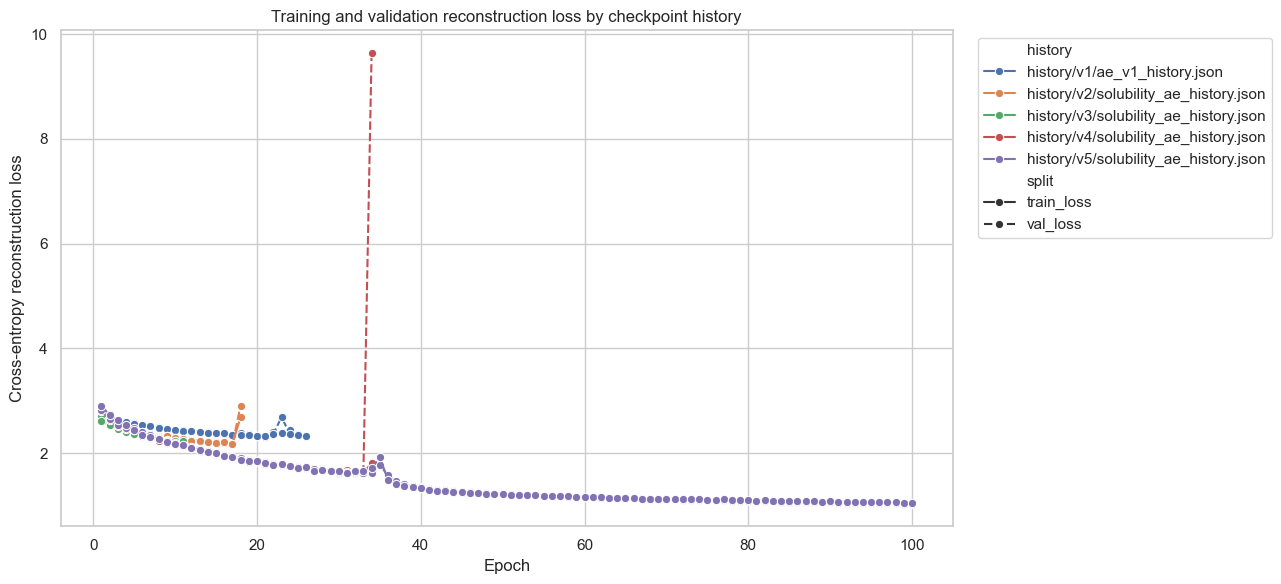

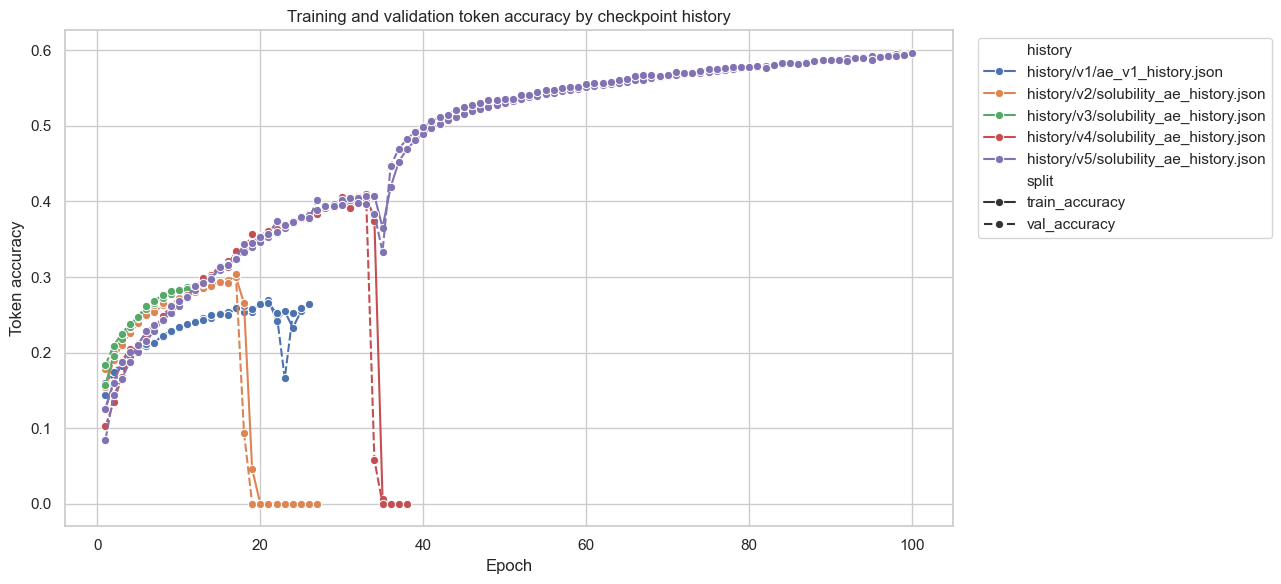

In [22]:
history_loss_long = plot_history_df.melt(
    id_vars=["history", "epoch"],
    value_vars=["train_loss", "val_loss"],
    var_name="split",
    value_name="loss",
).dropna(subset=["loss"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=history_loss_long,
    x="epoch",
    y="loss",
    hue="history",
    style="split",
    marker="o",
)
plt.title("Training and validation reconstruction loss by checkpoint history")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy reconstruction loss")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

history_acc_long = plot_history_df.melt(
    id_vars=["history", "epoch"],
    value_vars=["train_accuracy", "val_accuracy"],
    var_name="split",
    value_name="accuracy",
).dropna(subset=["accuracy"])

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=history_acc_long,
    x="epoch",
    y="accuracy",
    hue="history",
    style="split",
    marker="o",
)
plt.title("Training and validation token accuracy by checkpoint history")
plt.xlabel("Epoch")
plt.ylabel("Token accuracy")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

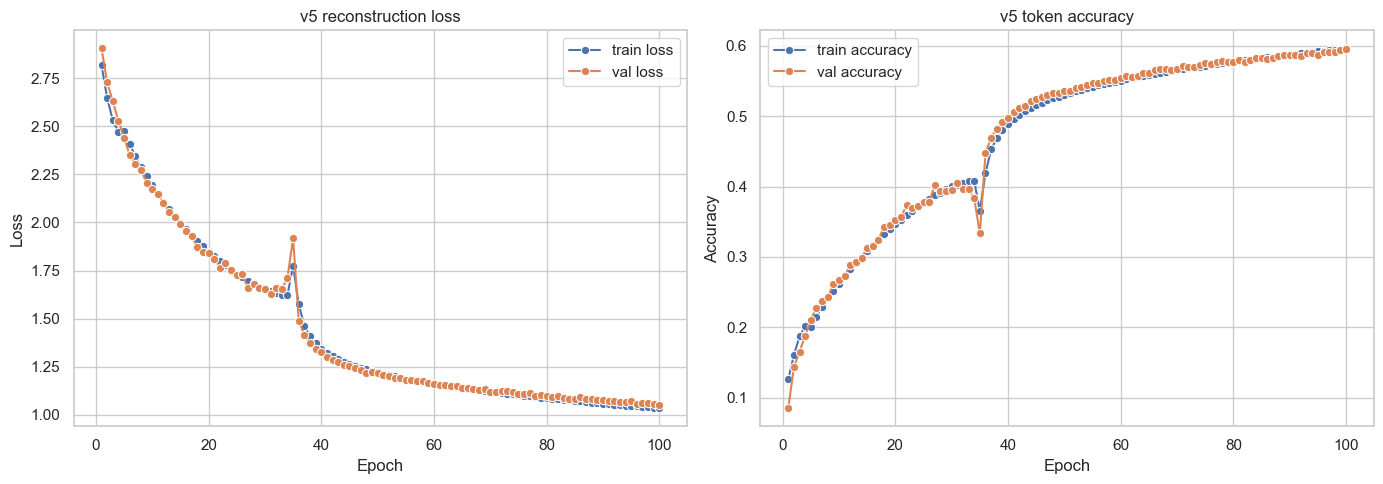

v5 epoch vs validation-loss Spearman rho=-0.997, p=1.01e-110


In [23]:
current_history_name = "history/v5/solubility_ae_history.json"
current_history_df = plot_history_df[plot_history_df["history"] == current_history_name].copy()

if current_history_df.empty:
    print(f"No rows found for {current_history_name}.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=current_history_df, x="epoch", y="train_loss", marker="o", label="train loss", ax=axes[0])
    sns.lineplot(data=current_history_df, x="epoch", y="val_loss", marker="o", label="val loss", ax=axes[0])
    axes[0].set_title("v5 reconstruction loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    sns.lineplot(data=current_history_df, x="epoch", y="train_accuracy", marker="o", label="train accuracy", ax=axes[1])
    sns.lineplot(data=current_history_df, x="epoch", y="val_accuracy", marker="o", label="val accuracy", ax=axes[1])
    axes[1].set_title("v5 token accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()

    if current_history_df["val_loss"].notna().sum() >= 3:
        rho, p = stats.spearmanr(current_history_df["epoch"], current_history_df["val_loss"], nan_policy="omit")
        print(f"v5 epoch vs validation-loss Spearman rho={rho:.3f}, p={p:.3g}")

## 7. Length Error Isolation Tests

The purpose of this section is to get a better understanding of why longer sequences are failing. Notably, there are a few important findings from the error analysis above.

- A. The amino acid error rate at each sequence length quartile is increasing, but mostly the same amino acids failing
- B. When evaluating error by position within the sequence, long sequences still struggle. This indicates that long sequences are all around not being represented well in the latent vector. (likely a good place to start experimenting)
- C. Error rate increases at absolute position. Although it still is bad early in long sequences.
- D. Certain amino acids have high error rates


<!-- TODO: -->
<!-- In testing script, add ability to test by sequence length (quartiles based) -->
<!-- Also while you are there, add the ability to test v6 checkpoints (they won't test well but you have to test them anyways) -->

### 7A. Data Coverage by Sequence Length

This checks whether long sequences are underrepresented or mismatched across train/valid/test. If the long-test bucket is much longer or rarer than what the model saw during training, the failure may be partly a data coverage problem.

,count,min,q25,median,q75,max,mean,std
split,,,,,,,,
test,1999,34,159.0,260.0,379.0,1200,296.329165,185.184135
train,62478,19,185.0,275.0,377.0,1200,298.242437,158.115356
valid,6942,27,187.0,275.0,378.0,1200,300.779891,164.221724


train_length_bin,long,medium-long,medium-short,short
split,,,,
test,0.253,0.209,0.223,0.315
train,0.249,0.250,0.250,0.251
valid,0.251,0.249,0.254,0.246


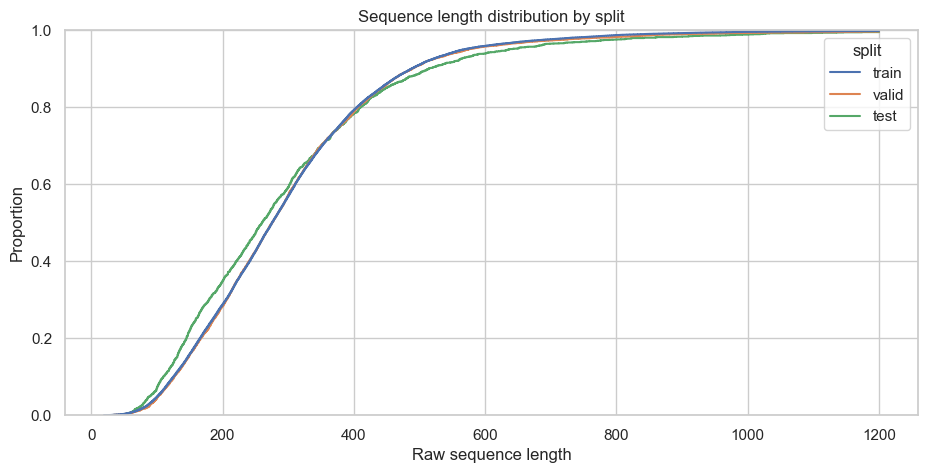

In [24]:
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "peer" / "solubility"

def load_split_lengths(split: str) -> pd.DataFrame:
    split_path = DATA_DIR / f"{split}.csv"
    df = pd.read_csv(split_path)
    df = df.dropna(subset=["sequence"]).copy()
    df["split"] = split
    df["raw_length"] = df["sequence"].astype(str).str.len()
    return df[["split", "sequence", "label", "raw_length"]]

split_lengths = pd.concat(
    [load_split_lengths(split) for split in ["train", "valid", "test"]],
    ignore_index=True,
)

train_boundaries = split_lengths.loc[split_lengths["split"] == "train", "raw_length"].quantile([0, 0.25, 0.5, 0.75, 1.0])
train_length_bins = pd.IntervalIndex.from_breaks(train_boundaries.to_numpy(), closed="right")

# Include the minimum training length in the first interval.
def assign_train_length_bin(length: int) -> str:
    labels = ["short", "medium-short", "medium-long", "long"]
    for idx, interval in enumerate(train_length_bins):
        if length in interval or (idx == 0 and length == interval.left):
            return labels[idx]
    if length <= train_length_bins[0].left:
        return "below-train-min"
    return "above-train-max"

split_lengths["train_length_bin"] = split_lengths["raw_length"].map(assign_train_length_bin)

coverage_summary = split_lengths.groupby("split")["raw_length"].agg(
    count="count",
    min="min",
    q25=lambda s: s.quantile(0.25),
    median="median",
    q75=lambda s: s.quantile(0.75),
    max="max",
    mean="mean",
    std="std",
)

display(coverage_summary)
display(pd.crosstab(split_lengths["split"], split_lengths["train_length_bin"], normalize="index").round(3))

plt.figure(figsize=(11, 5))
sns.ecdfplot(data=split_lengths, x="raw_length", hue="split")
plt.title("Sequence length distribution by split")
plt.xlabel("Raw sequence length")
plt.show()


### 7B. Load a Checkpoint for Direct Diagnostics

Set `CHECKPOINT_PATH` and `HISTORY_PATH` to the model you want to inspect. The default is the current full-solubility v5 checkpoint.

In [25]:
import sys

SRC_DIR = PROJECT_ROOT / "Code" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import torch
    import torch.nn.functional as F
    from models.autoencoder import ProteinSequenceAutoencoder as AE
    from utils.dataloader import (
        BOS_IDX,
        EOS_IDX,
        PAD_IDX,
        VOCAB,
        create_dataloader,
        collate_sequence_batch,
    )
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This diagnostic section requires the notebook kernel to have the project dependencies installed. "
        "Run it in the same environment used for training."
    ) from exc

CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "autoencoder" / "solubility" / "v5" / "model_ae_solubility.pt"
HISTORY_PATH = PROJECT_ROOT / "history" / "v5" / "solubility_ae_history.json"
TASK = "solubility"
EVAL_SPLIT = "test"
EVAL_BATCH_SIZE = 32
MAX_EVAL_BATCHES = None  # set to a small integer for a quick smoke test
DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "peer"
SPLIT_CSV = DATA_ROOT / TASK / f"{EVAL_SPLIT}.csv"
if not SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"Expected split CSV at {SPLIT_CSV}. "
        f"PROJECT_ROOT resolved to {PROJECT_ROOT}. "
        "If this is wrong, set PROJECT_ROOT manually at the top of the notebook."
    )

with HISTORY_PATH.open() as f:
    checkpoint_history = json.load(f)
hp = checkpoint_history["hyperparameters"]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)

model = AE(
    embedding_dim=hp["embedding_dim"],
    cnn_out_channels=hp["cnn_out_channels"],
    hidden_dim=hp["hidden_dim"],
    latent_dim=hp["latent_dim"],
    num_layers=hp["num_layers"],
    kernel_size=hp["kernel_size"],
    bidirectional=hp["bidirectional"],
    dropout=hp["dropout"],
    pad_idx=PAD_IDX,
    bos_idx=BOS_IDX,
    condition_decoder_on_latent=hp.get("condition_decoder_on_latent", True),
    teacher_forcing_dropout_rate=0.0,  # diagnostics should not randomly drop decoder inputs
).to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

analysis_loader = create_dataloader(
    task=TASK,
    split=EVAL_SPLIT,
    data_dir=DATA_ROOT,
    cache_dir=DATA_ROOT / "cache",
    mode="autoencoder",
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Data root: {DATA_ROOT}")
print(f"Split CSV: {SPLIT_CSV}")
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"Checkpoint epoch={checkpoint.get('epoch')}, val_loss={checkpoint.get('val_loss')}, val_accuracy={checkpoint.get('val_accuracy')}")
print(f"Diagnostic device: {device}")
print(f"Evaluation examples: {len(analysis_loader.dataset)}")


[cache] Loaded 1999 examples from cache: solubility_test_autoencoder_char_sequence_label_True_91ffec24.pkl
Data root: /Users/josh/GWU/protein-sequence-augmentation/data/processed/peer
Split CSV: /Users/josh/GWU/protein-sequence-augmentation/data/processed/peer/solubility/test.csv
Loaded checkpoint: /Users/josh/GWU/protein-sequence-augmentation/checkpoints/autoencoder/solubility/v5/model_ae_solubility.pt
Checkpoint epoch=100, val_loss=1.0504592219581668, val_accuracy=0.5962263646587327
Diagnostic device: mps
Evaluation examples: 1999


/Users/josh/GWU/protein-sequence-augmentation/Code/src/models/autoencoder.py:72: UserWarning: latent_dim should ideally be smaller than hidden_dim for effective compression
  warnings.warn("latent_dim should ideally be smaller than hidden_dim for effective compression", UserWarning)


### 7C. Teacher-Forced vs Free-Running Reconstruction by Length

Teacher-forced decoding uses the true previous token, matching the training/validation objective. Free-running decoding feeds the model's own predictions back into the decoder. If long sequences only fail free-running, the main issue is generation/exposure bias or EOS handling. If both fail, the problem is more likely data coverage, representation capacity, or optimization.

,n,mean_length,teacher_loss,teacher_acc,free_acc,teacher_eos_acc,free_eos_acc,free_abs_len_delta
length_bin,,,,,,,,
long,496,544.854839,1.546944,0.436596,0.141161,0.778226,0.854839,9.016129
medium-long,500,315.848000,0.953967,0.621599,0.227017,0.936000,0.882000,2.020000
medium-short,501,210.808383,0.554674,0.784027,0.387593,0.986028,0.684631,0.844311
short,502,116.683267,0.211964,0.919439,0.661794,0.996016,0.659363,0.458167


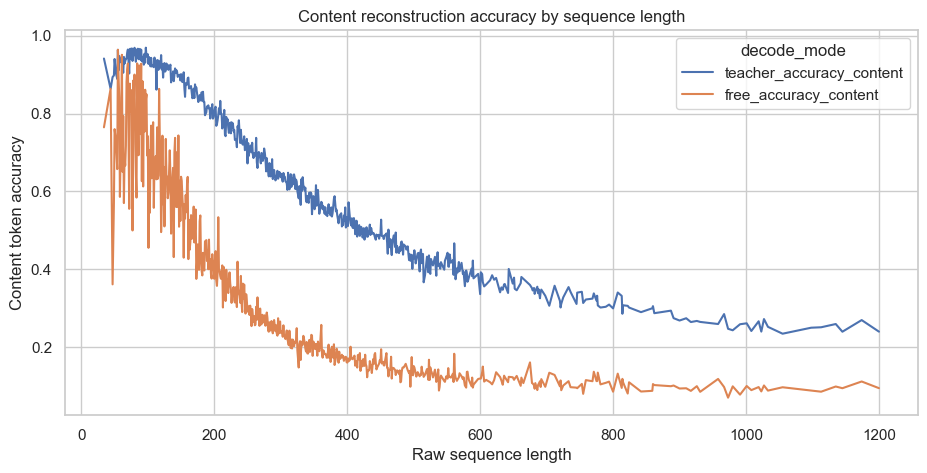

In [26]:
def first_eos_raw_length(pred_ids: torch.Tensor) -> int:
    eos_positions = (pred_ids == EOS_IDX).nonzero(as_tuple=False)
    if eos_positions.numel() == 0:
        return int(pred_ids.numel())
    return int(eos_positions[0].item())

def assign_eval_length_bins(lengths: pd.Series) -> pd.Series:
    labels = ["short", "medium-short", "medium-long", "long"]
    if lengths.empty:
        return pd.Series(dtype="object")
    if lengths.nunique(dropna=True) < 2:
        return pd.Series(["single-length"] * len(lengths), index=lengths.index, dtype="object")

    bins = pd.qcut(lengths, q=4, duplicates="drop")
    categories = list(bins.cat.categories)
    label_map = {category: labels[min(idx, len(labels) - 1)] for idx, category in enumerate(categories)}
    return bins.map(label_map).astype("object")

@torch.no_grad()
def evaluate_teacher_vs_free(model, dataloader, max_batches=None) -> pd.DataFrame:
    rows = []
    for batch_idx, batch in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        inputs = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        targets = batch["target_ids"].to(device)[:, 1:]  # amino acids plus EOS
        raw_lengths = (lengths - 2).detach().cpu().numpy()
        sequences = batch["sequence"]

        teacher_logits = model(inputs, decoder_input_ids=inputs[:, :-1], lengths=lengths)
        teacher_pred = teacher_logits.argmax(dim=-1)
        teacher_loss = F.cross_entropy(
            teacher_logits.reshape(-1, teacher_logits.size(-1)),
            targets.reshape(-1),
            ignore_index=PAD_IDX,
            reduction="none",
        ).view_as(targets)

        latent = model.encode(inputs, lengths=lengths)
        free_logits = model.decode(latent, decoder_input_ids=None, sequence_length=targets.size(1))
        free_pred = free_logits.argmax(dim=-1)

        for i in range(inputs.size(0)):
            target_i = targets[i]
            teacher_i = teacher_pred[i]
            free_i = free_pred[i]
            non_pad = target_i != PAD_IDX
            content = non_pad & (target_i != EOS_IDX)
            eos_target_positions = (target_i == EOS_IDX).nonzero(as_tuple=False)
            eos_pos = int(eos_target_positions[0].item()) if eos_target_positions.numel() else None
            raw_len = int(raw_lengths[i])
            pred_raw_len = first_eos_raw_length(free_i.detach().cpu())

            rows.append(
                {
                    "example_index": len(rows),
                    "sequence": sequences[i],
                    "raw_length": raw_len,
                    "teacher_loss": float(teacher_loss[i][non_pad].mean().detach().cpu()),
                    "teacher_accuracy_all": float((teacher_i[non_pad] == target_i[non_pad]).float().mean().detach().cpu()),
                    "teacher_accuracy_content": float((teacher_i[content] == target_i[content]).float().mean().detach().cpu()),
                    "teacher_eos_correct": bool(eos_pos is not None and teacher_i[eos_pos].item() == EOS_IDX),
                    "free_accuracy_all": float((free_i[non_pad] == target_i[non_pad]).float().mean().detach().cpu()),
                    "free_accuracy_content": float((free_i[content] == target_i[content]).float().mean().detach().cpu()),
                    "free_eos_correct": bool(eos_pos is not None and free_i[eos_pos].item() == EOS_IDX),
                    "free_predicted_raw_length": pred_raw_len,
                    "free_length_delta": pred_raw_len - raw_len,
                    "free_abs_length_delta": abs(pred_raw_len - raw_len),
                }
            )
    df = pd.DataFrame(rows)
    df["length_bin"] = assign_eval_length_bins(df["raw_length"])
    return df

direct_diag_df = evaluate_teacher_vs_free(model, analysis_loader, max_batches=MAX_EVAL_BATCHES)

metric_cols = [
    "teacher_loss",
    "teacher_accuracy_content",
    "free_accuracy_content",
    "teacher_eos_correct",
    "free_eos_correct",
    "free_abs_length_delta",
]
length_diag_summary = direct_diag_df.groupby("length_bin", observed=True).agg(
    n=("raw_length", "size"),
    mean_length=("raw_length", "mean"),
    teacher_loss=("teacher_loss", "mean"),
    teacher_acc=("teacher_accuracy_content", "mean"),
    free_acc=("free_accuracy_content", "mean"),
    teacher_eos_acc=("teacher_eos_correct", "mean"),
    free_eos_acc=("free_eos_correct", "mean"),
    free_abs_len_delta=("free_abs_length_delta", "mean"),
)

display(length_diag_summary)

plot_df = direct_diag_df.melt(
    id_vars=["raw_length", "length_bin"],
    value_vars=["teacher_accuracy_content", "free_accuracy_content"],
    var_name="decode_mode",
    value_name="content_accuracy",
)
plt.figure(figsize=(11, 5))
sns.lineplot(data=plot_df, x="raw_length", y="content_accuracy", hue="decode_mode", errorbar=None)
plt.title("Content reconstruction accuracy by sequence length")
plt.xlabel("Raw sequence length")
plt.ylabel("Content token accuracy")
plt.show()


### 7D. EOS and Length-Stop Failure Details

This focuses on whether the model stops too early, too late, or fails to emit EOS when decoding without teacher forcing.

free_length_error_type,exact,too_long_or_no_eos,too_short
length_bin,,,
long,0.006,0.016,0.978
medium-long,0.140,0.064,0.796
medium-short,0.439,0.295,0.265
short,0.620,0.335,0.046


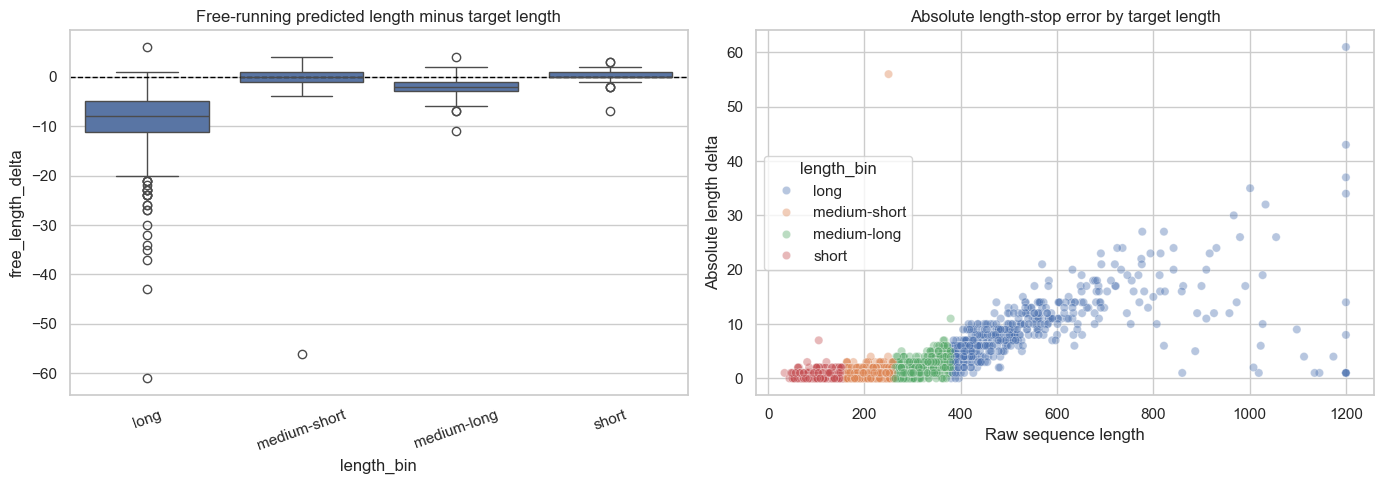

In [27]:
direct_diag_df["free_length_error_type"] = np.select(
    [
        direct_diag_df["free_length_delta"] < 0,
        direct_diag_df["free_length_delta"] == 0,
        direct_diag_df["free_length_delta"] > 0,
    ],
    ["too_short", "exact", "too_long_or_no_eos"],
    default="unknown"
)

display(pd.crosstab(
    direct_diag_df["length_bin"],
    direct_diag_df["free_length_error_type"],
    normalize="index",
).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=direct_diag_df, x="length_bin", y="free_length_delta", ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Free-running predicted length minus target length")
axes[0].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=direct_diag_df,
    x="raw_length",
    y="free_abs_length_delta",
    hue="length_bin",
    alpha=0.4,
    ax=axes[1],
)
axes[1].set_title("Absolute length-stop error by target length")
axes[1].set_xlabel("Raw sequence length")
axes[1].set_ylabel("Absolute length delta")
plt.tight_layout()
plt.show()


### 7E. Long-Sequence Prefix Stress Test

This uses the same long test proteins, truncates them to different prefix lengths, and reconstructs those prefixes. If a long protein's short prefix reconstructs well but the full sequence fails, that points toward compression/long-context limits. If even short prefixes from long proteins fail, the issue may be sequence composition or underlearned amino-acid patterns rather than length alone.

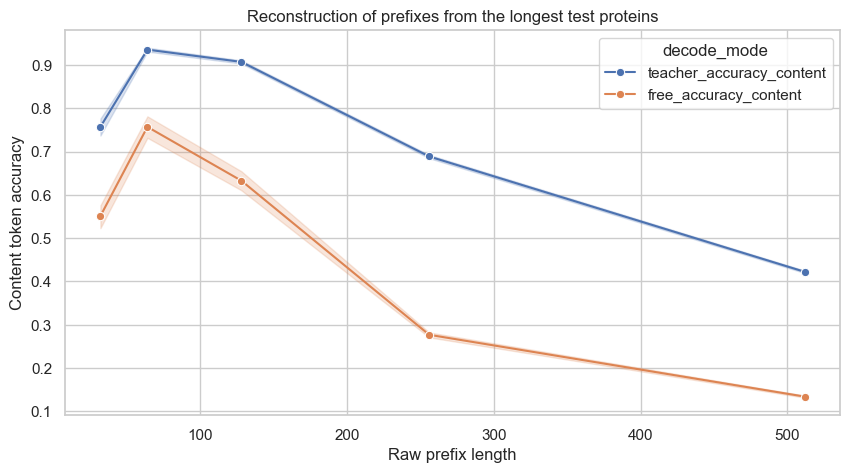

In [28]:
IDX_TO_TOKEN = {idx: token for token, idx in VOCAB.items()}

def encode_raw_sequence(sequence: str) -> torch.Tensor:
    token_ids = [BOS_IDX] + [VOCAB.get(aa, VOCAB["<UNK>"]) for aa in sequence] + [EOS_IDX]
    return torch.tensor(token_ids, dtype=torch.long)

def make_prefix_loader(sequences: list[str], prefix_length: int, batch_size: int = 32):
    examples = []
    for sequence in sequences:
        prefix = sequence[:prefix_length]
        input_ids = encode_raw_sequence(prefix)
        examples.append(
            {
                "input_ids": input_ids,
                "target_ids": input_ids.clone(),
                "length": torch.tensor(len(input_ids), dtype=torch.long),
                "sequence": prefix,
            }
        )
    return torch.utils.data.DataLoader(
        examples,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_sequence_batch,
    )

long_sequences = direct_diag_df.sort_values("raw_length", ascending=False)["sequence"].head(256).tolist()
prefix_lengths = [32, 64, 128, 256, 512]
prefix_lengths = [length for length in prefix_lengths if any(len(seq) >= length for seq in long_sequences)]

prefix_frames = []
for prefix_length in prefix_lengths:
    eligible_sequences = [seq for seq in long_sequences if len(seq) >= prefix_length]
    prefix_loader = make_prefix_loader(eligible_sequences, prefix_length, batch_size=EVAL_BATCH_SIZE)
    prefix_df = evaluate_teacher_vs_free(model, prefix_loader, max_batches=None)
    prefix_df["prefix_length"] = prefix_length
    prefix_frames.append(prefix_df)

prefix_diag_df = pd.concat(prefix_frames, ignore_index=True)

prefix_summary = prefix_diag_df.groupby("prefix_length").agg(
    n=("raw_length", "size"),
    teacher_loss=("teacher_loss", "mean"),
    teacher_acc=("teacher_accuracy_content", "mean"),
    free_acc=("free_accuracy_content", "mean"),
    free_eos_acc=("free_eos_correct", "mean"),
    free_abs_len_delta=("free_abs_length_delta", "mean"),
)

# display(prefix_summary)

prefix_plot_df = prefix_diag_df.melt(
    id_vars=["prefix_length"],
    value_vars=["teacher_accuracy_content", "free_accuracy_content"],
    var_name="decode_mode",
    value_name="content_accuracy",
)
plt.figure(figsize=(10, 5))
sns.lineplot(data=prefix_plot_df, x="prefix_length", y="content_accuracy", hue="decode_mode", marker="o")
plt.title("Reconstruction of prefixes from the longest test proteins")
plt.xlabel("Raw prefix length")
plt.ylabel("Content token accuracy")
plt.show()


In [29]:
prefix_summary = prefix_diag_df.groupby("prefix_length").agg(
    n=("raw_length", "size"),
    teacher_loss=("teacher_loss", "mean"),
    teacher_acc=("teacher_accuracy_content", "mean"),
    free_acc=("free_accuracy_content", "mean"),
    free_eos_acc=("free_eos_correct", "mean"),
    free_abs_len_delta=("free_abs_length_delta", "mean"),
)

display(prefix_summary)


,n,teacher_loss,teacher_acc,free_acc,free_eos_acc,free_abs_len_delta
prefix_length,,,,,,
32,256,1.433537,0.757202,0.551147,0.742188,1.417969
64,256,0.187695,0.935425,0.757019,0.675781,0.398438
128,256,0.240801,0.907074,0.632812,0.691406,0.343750
256,256,0.766222,0.688660,0.276871,0.855469,0.980469
512,204,1.571728,0.422124,0.134038,0.975490,9.495098


### 7F. Quick Interpretation Guide

Use these patterns to decide the next experiment:

- Data/training problem: long sequences are rare in train, train/valid/test length distributions differ, or both teacher-forced and free-running metrics degrade similarly with length.
- Representation problem: teacher-forced accuracy/loss degrades strongly with length, and long-protein prefixes are much easier than full long proteins.
- Generation problem: teacher-forced metrics are acceptable but free-running accuracy, EOS accuracy, or length delta collapses for long sequences.
- EOS-specific problem: content accuracy is reasonable but free-running EOS accuracy and length delta are poor.


## 8. Identifying the positions with the largest dropoff in error. That meaning, what sequence lengths have the highest dropoff points

This section looks for sharp reconstruction dropoffs in two ways:

- sequence-length thresholds where per-example reconstruction error increases fastest
- within-sequence absolute/relative positions where token error increases fastest

Missing predicted positions are counted as token errors, so early stopping contributes to the dropoff analysis.

In [30]:
# Build a token-level table from saved reconstruction outputs.
# This is intentionally based on output_results.csv so it can run without loading a checkpoint.
position_dropoff_rows = []
for row in results.itertuples(index=False):
    target = str(row.target_sequence)
    predicted = str(row.predicted_sequence)
    target_len = int(row.target_length)
    length_bin = row.length_bin

    if target_len <= 0:
        continue

    for pos, target_aa in enumerate(target):
        predicted_aa = predicted[pos] if pos < len(predicted) else "<MISSING>"
        position_dropoff_rows.append(
            {
                "target_length": target_len,
                "length_bin": length_bin,
                "absolute_position": pos + 1,
                "relative_position": (pos + 1) / target_len,
                "target_aa": target_aa,
                "predicted_aa": predicted_aa,
                "error": int(predicted_aa != target_aa),
                "missing_prediction": int(predicted_aa == "<MISSING>"),
            }
        )

position_dropoff_df = pd.DataFrame(position_dropoff_rows)
print(f"Token rows: {len(position_dropoff_df):,}")
display(position_dropoff_df.head())


Token rows: 318,328


,target_length,length_bin,absolute_position,relative_position,target_aa,predicted_aa,error,missing_prediction
0,222,medium-long,1,0.004505,M,M,0,0
1,222,medium-long,2,0.009009,A,A,0,0
2,222,medium-long,3,0.013514,N,N,0,0
3,222,medium-long,4,0.018018,M,L,1,0
4,222,medium-long,5,0.022523,L,L,0,0


### 8A. Sequence-Length Dropoff Points

This finds length ranges where average reconstruction error increases fastest as target length grows.

,length_window,n_examples,length_midpoint,mean_error,median_error,mean_token_accuracy,mean_abs_length_delta,error_delta_from_previous,length_delta_from_previous,error_slope_per_100aa,previous_window,dropoff_transition
0,"(-0.001, 50.0]",5,44.800000,0.090693,0.100000,0.909307,0.000000,NaN,NaN,NaN,NaN,NaN
1,"(50.0, 100.0]",143,81.916084,0.053347,0.050000,0.946653,0.006993,-0.037346,37.116084,-0.100621,"(-0.001, 50.0]","(-0.001, 50.0] -> (50.0, 100.0]"
2,"(100.0, 150.0]",297,127.303030,0.084828,0.081818,0.915172,0.020202,0.031481,45.386946,0.069361,"(50.0, 100.0]","(50.0, 100.0] -> (100.0, 150.0]"
3,"(150.0, 200.0]",254,174.094488,0.152347,0.149255,0.847653,0.015748,0.067519,46.791458,0.144297,"(100.0, 150.0]","(100.0, 150.0] -> (150.0, 200.0]"
4,"(200.0, 250.0]",251,225.884462,0.240324,0.236364,0.759676,0.043825,0.087977,51.789974,0.169873,"(150.0, 200.0]","(150.0, 200.0] -> (200.0, 250.0]"
5,"(250.0, 300.0]",236,274.258475,0.322408,0.321428,0.677592,0.110169,0.082085,48.374012,0.169688,"(200.0, 250.0]","(200.0, 250.0] -> (250.0, 300.0]"
6,"(300.0, 350.0]",215,323.106977,0.387079,0.386628,0.612921,0.186047,0.064671,48.848502,0.132391,"(250.0, 300.0]","(250.0, 300.0] -> (300.0, 350.0]"
7,"(350.0, 400.0]",92,363.815217,0.440408,0.447188,0.559592,0.380435,0.053329,40.708241,0.131002,"(300.0, 350.0]","(300.0, 350.0] -> (350.0, 400.0]"


Largest length-window error increases:


,dropoff_transition,n_examples,length_midpoint,mean_error,error_delta_from_previous,error_slope_per_100aa,mean_abs_length_delta
4,"(150.0, 200.0] -> (200.0, 250.0]",251,225.884462,0.240324,0.087977,0.169873,0.043825
5,"(200.0, 250.0] -> (250.0, 300.0]",236,274.258475,0.322408,0.082085,0.169688,0.110169
3,"(100.0, 150.0] -> (150.0, 200.0]",254,174.094488,0.152347,0.067519,0.144297,0.015748
6,"(250.0, 300.0] -> (300.0, 350.0]",215,323.106977,0.387079,0.064671,0.132391,0.186047
7,"(300.0, 350.0] -> (350.0, 400.0]",92,363.815217,0.440408,0.053329,0.131002,0.380435
2,"(50.0, 100.0] -> (100.0, 150.0]",297,127.303030,0.084828,0.031481,0.069361,0.020202
1,"(-0.001, 50.0] -> (50.0, 100.0]",143,81.916084,0.053347,-0.037346,-0.100621,0.006993


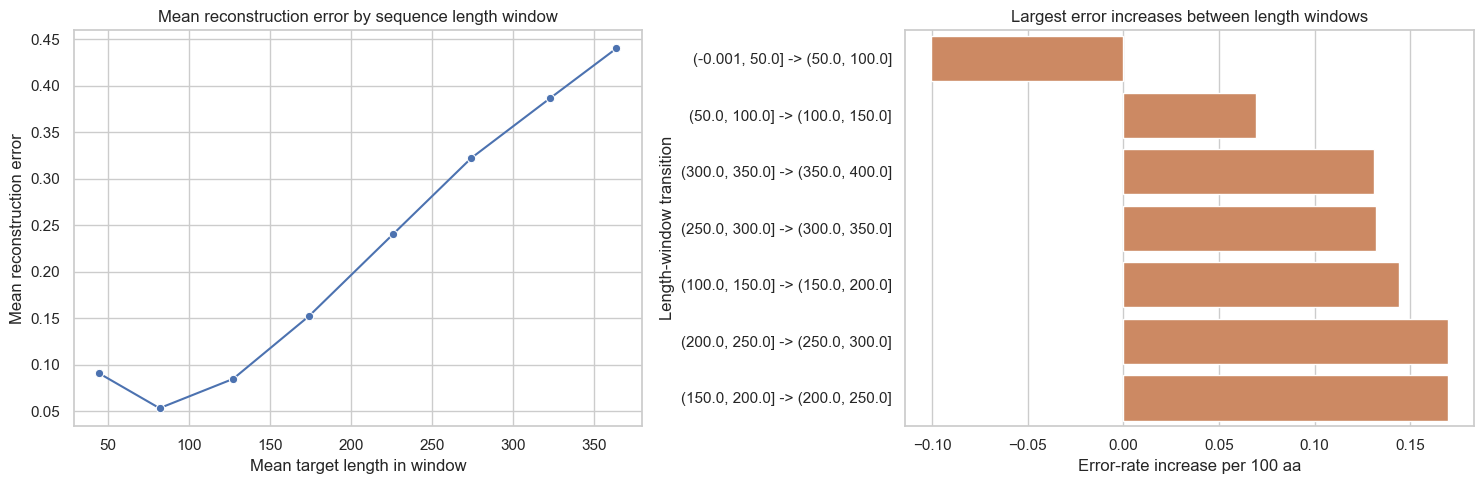

In [31]:
LENGTH_BIN_WIDTH = 50
MAX_LENGTH_FOR_DROPOFF = int(np.ceil(results["target_length"].max() / LENGTH_BIN_WIDTH) * LENGTH_BIN_WIDTH)
length_edges = np.arange(
    0,
    MAX_LENGTH_FOR_DROPOFF + LENGTH_BIN_WIDTH,
    LENGTH_BIN_WIDTH,
    dtype=float,
).tolist()

length_dropoff_df = results.copy()
length_dropoff_df["length_window"] = pd.cut(
    length_dropoff_df["target_length"],
    bins=length_edges,
    include_lowest=True,
)

length_window_summary = (
    length_dropoff_df.groupby("length_window", observed=True)
    .agg(
        n_examples=("target_length", "size"),
        length_midpoint=("target_length", "mean"),
        mean_error=("reconstruction_error", "mean"),
        median_error=("reconstruction_error", "median"),
        mean_token_accuracy=("token_accuracy", "mean"),
        mean_abs_length_delta=("abs_length_delta", "mean"),
    )
    .reset_index()
    .sort_values("length_midpoint")
)

# Sparse high-length windows can create noisy jumps, so require enough examples.
MIN_EXAMPLES_PER_LENGTH_WINDOW = 20
length_window_summary["error_delta_from_previous"] = length_window_summary["mean_error"].diff()
length_window_summary["length_delta_from_previous"] = length_window_summary["length_midpoint"].diff()
length_window_summary["error_slope_per_100aa"] = (
    length_window_summary["error_delta_from_previous"]
    / length_window_summary["length_delta_from_previous"]
    * 100
)
length_window_summary["previous_window"] = length_window_summary["length_window"].shift(1)
length_window_summary["dropoff_transition"] = (
    length_window_summary["previous_window"].astype(str)
    + " -> "
    + length_window_summary["length_window"].astype(str)
)

largest_length_dropoffs = (
    length_window_summary[length_window_summary["n_examples"] >= MIN_EXAMPLES_PER_LENGTH_WINDOW]
    .dropna(subset=["error_slope_per_100aa"])
    .sort_values("error_slope_per_100aa", ascending=False)
    .head(10)
)

display(length_window_summary)
print("Largest length-window error increases:")
display(
    largest_length_dropoffs[
        [
            "dropoff_transition",
            "n_examples",
            "length_midpoint",
            "mean_error",
            "error_delta_from_previous",
            "error_slope_per_100aa",
            "mean_abs_length_delta",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(
    data=length_window_summary,
    x="length_midpoint",
    y="mean_error",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean reconstruction error by sequence length window")
axes[0].set_xlabel("Mean target length in window")
axes[0].set_ylabel("Mean reconstruction error")

sns.barplot(
    data=largest_length_dropoffs.sort_values("error_slope_per_100aa", ascending=True),
    y="dropoff_transition",
    x="error_slope_per_100aa",
    color="#dd8452",
    ax=axes[1],
)
axes[1].set_title("Largest error increases between length windows")
axes[1].set_xlabel("Error-rate increase per 100 aa")
axes[1].set_ylabel("Length-window transition")
plt.tight_layout()
plt.show()


### 8B. Absolute Position Dropoff Points

This asks where token error increases most sharply as the decoder moves through the sequence. Results are separated by sequence-length bucket so long-sequence-specific failures are easier to see.

Largest absolute-position error increases:


,length_bin,dropoff_position,n_tokens,position_midpoint,error_rate,error_delta_from_previous,error_slope_per_100_positions,missing_prediction_rate
1,long,"(25.0, 50.0]",9250,38.000000,0.361514,0.158162,0.632649,0.000000
17,medium-long,"(25.0, 50.0]",9250,38.000000,0.270486,0.086486,0.345946,0.000000
34,medium-short,"(150.0, 175.0]",5915,161.763821,0.188504,0.035512,0.147709,0.000507
12,long,"(300.0, 325.0]",5980,311.950669,0.498662,0.030884,0.126988,0.002174
24,medium-long,"(200.0, 225.0]",8810,212.600227,0.329852,0.023474,0.095422,0.000000
42,short,"(125.0, 150.0]",861,130.871080,0.095238,0.017492,0.090396,0.002323
8,long,"(200.0, 225.0]",9250,213.000000,0.421081,0.019351,0.077405,0.000000
25,medium-long,"(225.0, 250.0]",6032,236.901194,0.347977,0.018125,0.074586,0.000829
9,long,"(225.0, 250.0]",9250,238.000000,0.439027,0.017946,0.071784,0.000000
10,long,"(250.0, 275.0]",9250,263.000000,0.456757,0.017730,0.070919,0.000000


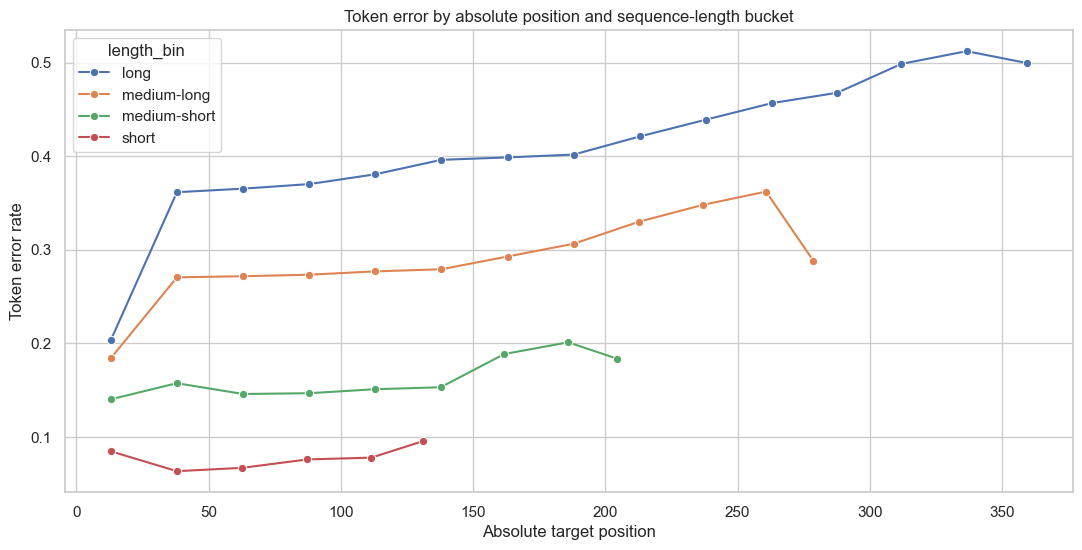

In [32]:
if "position_dropoff_df" not in globals():
    if "position_df" in globals():
        position_dropoff_df = position_df.copy()
    else:
        position_dropoff_df = pd.DataFrame(position_rows)

if "missing_prediction" not in position_dropoff_df.columns:
    position_dropoff_df["missing_prediction"] = (
        position_dropoff_df["predicted_aa"] == "<MISSING>"
    ).astype(int)

ABS_POSITION_BIN_WIDTH = 25
max_position = int(np.ceil(position_dropoff_df["absolute_position"].max() / ABS_POSITION_BIN_WIDTH) * ABS_POSITION_BIN_WIDTH)
absolute_position_edges = np.arange(0, max_position + ABS_POSITION_BIN_WIDTH, ABS_POSITION_BIN_WIDTH)

position_dropoff_df["absolute_position_bin"] = pd.cut(
    position_dropoff_df["absolute_position"],
    bins=absolute_position_edges,
    include_lowest=True,
)

absolute_position_summary = (
    position_dropoff_df.groupby(["length_bin", "absolute_position_bin"], observed=True)
    .agg(
        n_tokens=("error", "size"),
        position_midpoint=("absolute_position", "mean"),
        error_rate=("error", "mean"),
        missing_prediction_rate=("missing_prediction", "mean"),
    )
    .reset_index()
    .sort_values(["length_bin", "position_midpoint"])
)

MIN_TOKENS_PER_POSITION_BIN = 100
absolute_position_summary["previous_error_rate"] = absolute_position_summary.groupby("length_bin", observed=True)["error_rate"].shift(1)
absolute_position_summary["previous_position_midpoint"] = absolute_position_summary.groupby("length_bin", observed=True)["position_midpoint"].shift(1)
absolute_position_summary["error_delta_from_previous"] = absolute_position_summary["error_rate"] - absolute_position_summary["previous_error_rate"]
absolute_position_summary["position_delta_from_previous"] = absolute_position_summary["position_midpoint"] - absolute_position_summary["previous_position_midpoint"]
absolute_position_summary["error_slope_per_100_positions"] = (
    absolute_position_summary["error_delta_from_previous"]
    / absolute_position_summary["position_delta_from_previous"]
    * 100
)
absolute_position_summary["dropoff_position"] = absolute_position_summary["absolute_position_bin"].astype(str)

top_absolute_position_dropoffs = (
    absolute_position_summary[absolute_position_summary["n_tokens"] >= MIN_TOKENS_PER_POSITION_BIN]
    .dropna(subset=["error_slope_per_100_positions"])
    .sort_values("error_slope_per_100_positions", ascending=False)
    .head(20)
)

print("Largest absolute-position error increases:")
display(
    top_absolute_position_dropoffs[
        [
            "length_bin",
            "dropoff_position",
            "n_tokens",
            "position_midpoint",
            "error_rate",
            "error_delta_from_previous",
            "error_slope_per_100_positions",
            "missing_prediction_rate",
        ]
    ]
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=absolute_position_summary[absolute_position_summary["n_tokens"] >= MIN_TOKENS_PER_POSITION_BIN],
    x="position_midpoint",
    y="error_rate",
    hue="length_bin",
    marker="o",
)
plt.title("Token error by absolute position and sequence-length bucket")
plt.xlabel("Absolute target position")
plt.ylabel("Token error rate")
plt.show()


### 8C. Relative Position Dropoff Points

This normalizes position by sequence length. If long sequences fail early even at low relative positions, that supports a representation problem. If failures mainly happen late, that points more toward autoregressive drift or EOS/stop behavior.

Largest relative-position error increases:


,length_bin,dropoff_relative_position,n_tokens,relative_position_midpoint,error_rate,error_delta_from_previous,error_slope_per_full_sequence,missing_prediction_rate
1,long,"(0.05, 0.1]",6078,0.075146,0.341889,0.207459,4.206388,0.0
21,medium-long,"(0.05, 0.1]",4614,0.075109,0.264196,0.165716,3.375706,0.0
41,medium-short,"(0.05, 0.1]",3244,0.075256,0.172010,0.112919,2.321186,0.0
61,short,"(0.05, 0.1]",2017,0.075368,0.107090,0.073665,1.540749,0.0
14,long,"(0.7, 0.75]",6091,0.725233,0.451486,0.028264,0.563434,0.0
7,long,"(0.35, 0.4]",6096,0.375197,0.397146,0.027666,0.552245,0.0
17,long,"(0.85, 0.9]",6071,0.875073,0.484928,0.027175,0.544989,0.0
42,medium-short,"(0.1, 0.15]",3240,0.125154,0.198457,0.026447,0.530012,0.0
2,long,"(0.1, 0.15]",6050,0.125096,0.361488,0.019599,0.392368,0.0
74,short,"(0.7, 0.75]",2029,0.725894,0.079842,0.019072,0.377374,0.0


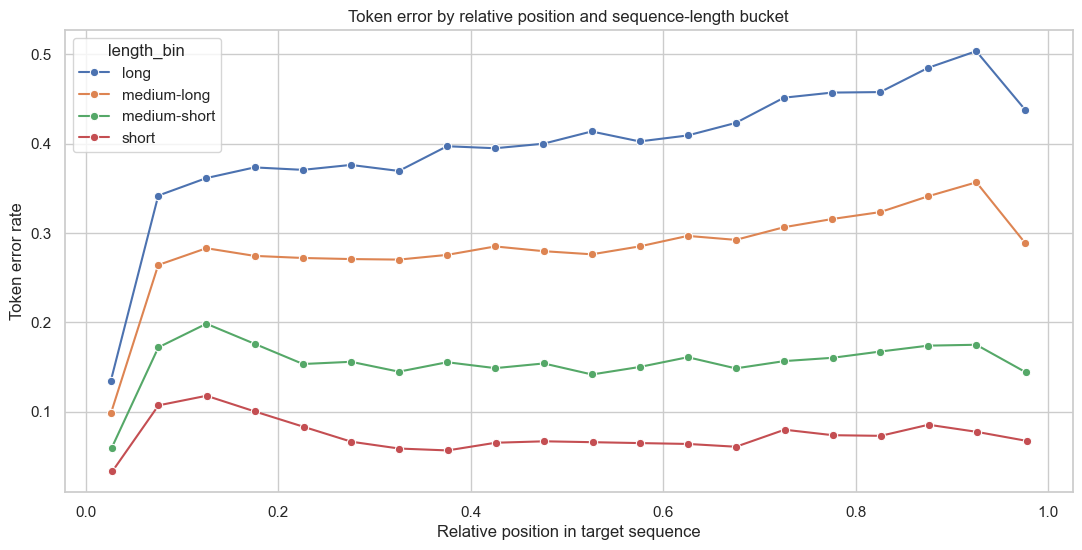

In [33]:
RELATIVE_POSITION_BIN_WIDTH = 0.05
relative_position_edges = np.arange(0, 1 + RELATIVE_POSITION_BIN_WIDTH, RELATIVE_POSITION_BIN_WIDTH)
position_dropoff_df["relative_position_bin"] = pd.cut(
    position_dropoff_df["relative_position"],
    bins=relative_position_edges,
    include_lowest=True,
)

relative_position_summary = (
    position_dropoff_df.groupby(["length_bin", "relative_position_bin"], observed=True)
    .agg(
        n_tokens=("error", "size"),
        relative_position_midpoint=("relative_position", "mean"),
        error_rate=("error", "mean"),
        missing_prediction_rate=("missing_prediction", "mean"),
    )
    .reset_index()
    .sort_values(["length_bin", "relative_position_midpoint"])
)

relative_position_summary["previous_error_rate"] = relative_position_summary.groupby("length_bin", observed=True)["error_rate"].shift(1)
relative_position_summary["previous_relative_position"] = relative_position_summary.groupby("length_bin", observed=True)["relative_position_midpoint"].shift(1)
relative_position_summary["error_delta_from_previous"] = relative_position_summary["error_rate"] - relative_position_summary["previous_error_rate"]
relative_position_summary["relative_position_delta"] = relative_position_summary["relative_position_midpoint"] - relative_position_summary["previous_relative_position"]
relative_position_summary["error_slope_per_full_sequence"] = (
    relative_position_summary["error_delta_from_previous"]
    / relative_position_summary["relative_position_delta"]
)
relative_position_summary["dropoff_relative_position"] = relative_position_summary["relative_position_bin"].astype(str)

top_relative_position_dropoffs = (
    relative_position_summary.dropna(subset=["error_slope_per_full_sequence"])
    .sort_values("error_slope_per_full_sequence", ascending=False)
    .head(20)
)

print("Largest relative-position error increases:")
display(
    top_relative_position_dropoffs[
        [
            "length_bin",
            "dropoff_relative_position",
            "n_tokens",
            "relative_position_midpoint",
            "error_rate",
            "error_delta_from_previous",
            "error_slope_per_full_sequence",
            "missing_prediction_rate",
        ]
    ]
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=relative_position_summary,
    x="relative_position_midpoint",
    y="error_rate",
    hue="length_bin",
    marker="o",
)
plt.title("Token error by relative position and sequence-length bucket")
plt.xlabel("Relative position in target sequence")
plt.ylabel("Token error rate")
plt.show()


### 8D. First Error-Rate Threshold Crossings

These tables identify the earliest position where each length bucket crosses common error-rate thresholds. This gives a compact answer to “where does reconstruction become unreliable?”

In [34]:
def first_threshold_crossings(summary: pd.DataFrame, group_col: str, position_col: str, label_col: str, thresholds=(0.25, 0.5, 0.75)) -> pd.DataFrame:
    rows = []
    for group_name, group in summary.sort_values(position_col).groupby(group_col, observed=True):
        for threshold in thresholds:
            crossed = group[group["error_rate"] >= threshold]
            if crossed.empty:
                rows.append(
                    {
                        group_col: group_name,
                        "threshold": threshold,
                        label_col: None,
                        position_col: np.nan,
                        "error_rate": np.nan,
                        "missing_prediction_rate": np.nan,
                    }
                )
            else:
                first = crossed.iloc[0]
                rows.append(
                    {
                        group_col: group_name,
                        "threshold": threshold,
                        label_col: first[label_col],
                        position_col: first[position_col],
                        "error_rate": first["error_rate"],
                        "missing_prediction_rate": first["missing_prediction_rate"],
                    }
                )
    return pd.DataFrame(rows)

absolute_threshold_crossings = first_threshold_crossings(
    absolute_position_summary[absolute_position_summary["n_tokens"] >= MIN_TOKENS_PER_POSITION_BIN],
    group_col="length_bin",
    position_col="position_midpoint",
    label_col="dropoff_position",
)
relative_threshold_crossings = first_threshold_crossings(
    relative_position_summary,
    group_col="length_bin",
    position_col="relative_position_midpoint",
    label_col="dropoff_relative_position",
)

print("Earliest absolute positions crossing each error threshold:")
display(absolute_threshold_crossings)
print("Earliest relative positions crossing each error threshold:")
display(relative_threshold_crossings)


Earliest absolute positions crossing each error threshold:


,length_bin,threshold,dropoff_position,position_midpoint,error_rate,missing_prediction_rate
0,long,0.25,"(25.0, 50.0]",38.000000,0.361514,0.000000
1,long,0.50,"(325.0, 350.0]",336.621237,0.512263,0.004181
2,long,0.75,NaN,NaN,NaN,NaN
3,medium-long,0.25,"(25.0, 50.0]",38.000000,0.270486,0.000000
4,medium-long,0.50,NaN,NaN,NaN,NaN
5,medium-long,0.75,NaN,NaN,NaN,NaN
6,medium-short,0.25,NaN,NaN,NaN,NaN
7,medium-short,0.50,NaN,NaN,NaN,NaN
8,medium-short,0.75,NaN,NaN,NaN,NaN
9,short,0.25,NaN,NaN,NaN,NaN


Earliest relative positions crossing each error threshold:


,length_bin,threshold,dropoff_relative_position,relative_position_midpoint,error_rate,missing_prediction_rate
0,long,0.25,"(0.05, 0.1]",0.075146,0.341889,0.0
1,long,0.50,"(0.9, 0.95]",0.925023,0.503550,0.0
2,long,0.75,NaN,NaN,NaN,NaN
3,medium-long,0.25,"(0.05, 0.1]",0.075109,0.264196,0.0
4,medium-long,0.50,NaN,NaN,NaN,NaN
5,medium-long,0.75,NaN,NaN,NaN,NaN
6,medium-short,0.25,NaN,NaN,NaN,NaN
7,medium-short,0.50,NaN,NaN,NaN,NaN
8,medium-short,0.75,NaN,NaN,NaN,NaN
9,short,0.25,NaN,NaN,NaN,NaN


Ideas for moving forward.

- Problem: Long sequences seem to be notoriously difficult to reconstruct from latent space. It is possible, that the best course of action is to not perform augmentation on long sequences. Here are the options we have:

1. Continue training with current training distribution, but only test and validate on sets that exclude the top 25-percentile of length.
2. Train with only the bottom 75% of proteins sequence lengths. Then make sure your test set follows that protocol as well.
3. Do a curriculum style thing but where you start with the longer sequences so they model sees them early, and slowly remove long samples until there are no more samples of lengths higher than the threshold set.


- In the end, the goal is to have the model only perform augmentation on the bottom 75% of protein sequence lengths.